# Week 2 — Day 2: Does Memory Help?

Day 1 used an MLP. Day 2 keeps the same stock, data pipeline, target, train/test split, and evaluation, and only swaps the architecture to an LSTM. The goal is to test whether adding memory improves real-stock prediction performance on the same ABUK experiment.


## What "Memory" Means Here

The Day 1 MLP treats each observation as one fixed feature vector. The LSTM instead reads a short chronological sequence of feature vectors, so its hidden state and cell state can carry information from earlier steps in the window into the next-day return prediction.


In [192]:
from pathlib import Path
import os
import sys

import numpy as np
import torch

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "tradinglab").exists()
)
os.chdir(repo_root)

tmp_dir = repo_root / ".tmp"
(tmp_dir / "matplotlib").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(tmp_dir / "matplotlib"))

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from tradinglab.data_feed import DataFeed
from tradinglab.features import FEATURE_NAMES, build_pooled_dataset, build_pooled_sequences
from tradinglab.metrics import directional_accuracy, information_coefficient
from tradinglab.ml import predict, train_model
from tradinglab.models import LSTMRegressor, MLP


def set_seed(seed: int = 0):
    np.random.seed(seed)
    torch.manual_seed(seed)


def mse(actual, predicted) -> float:
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    return float(np.mean((actual - predicted) ** 2))


def plot_loss(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history["train"], label="Train loss")
    plt.plot(history["test"], label="Test loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_predictions(actual, predicted, title):
    plt.figure(figsize=(12, 4))
    plt.plot(actual, label="Actual", linewidth=1.6)
    plt.plot(predicted, label="Predicted", linewidth=1.2)
    plt.xlabel("Sample")
    plt.ylabel("Next-day return")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def metrics_dict(actual, predicted):
    return {
        "mse": mse(actual, predicted),
        "directional_accuracy": directional_accuracy(predicted, actual),
        "information_coefficient": information_coefficient(predicted, actual),
    }


seed = 0
set_seed(seed)
print(f"Repo root: {repo_root}")
print(f"CUDA available: {torch.cuda.is_available()} (Week 2 uses CPU)")


Repo root: c:\Users\alyka\Documents\2026-orion
CUDA available: False (Week 2 uses CPU)


In [193]:
symbol = "ABUK"
# symbol = "COMI"
data_dir = repo_root / "data" / "egx"
feed = DataFeed.from_dir(str(data_dir), symbols=[symbol])
asset = 0

split_day = int(feed.n_days * 0.7)
split_date = feed.dates[split_day]
seq_len = 5
hidden = 32
# hidden = 25
# epochs = 200
epochs = 120
lr = 0.01

print(f"Stock: {symbol}")
print(f"Date range: {feed.dates[0]} -> {feed.dates[-1]}")
print(f"Chronological split day: {split_day} ({split_date})")
print(f"Feature set: {FEATURE_NAMES}")
print("Target: next-day return")
print("Scaling/normalization: none in Day 1, so none added here")
print(f"LSTM sequence length from Week 2 Day 2: {seq_len}")


Stock: ABUK
Date range: 2015-01-04 00:00:00 -> 2026-07-30 00:00:00
Chronological split day: 1999 (2023-01-11 00:00:00)
Feature set: ['return', 'p/sma_fast', 'p/sma_slow', 'rsi', 'volatility']
Target: next-day return
Scaling/normalization: none in Day 1, so none added here
LSTM sequence length from Week 2 Day 2: 5


## Fair Comparison Setup

Day 1 predicts the same next-day return from the same five engineered features with the same 70/30 chronological split. The only structural change is that the LSTM consumes a five-step sequence instead of a single row. Because each split loses its first `seq_len` rows as sequence warm-up, the MLP baseline below is trimmed to the exact same aligned labels so the comparison stays fair.


In [194]:
X_train_full, y_train_full, X_test_full, y_test_full = build_pooled_dataset(feed, split_day)
X_train_seq, y_train_seq, X_test_seq, y_test_seq = build_pooled_sequences(feed, split_day, seq_len=seq_len)

X_train = X_train_full[seq_len:]
y_train = y_train_full[seq_len:]
X_test = X_test_full[seq_len:]
y_test = y_test_full[seq_len:]

# batch_first=True in the Week 2 LSTM helper, so the expected shape is:
# (batch, sequence, features)
assert X_train_seq.ndim == 3 and X_train_seq.shape[1] == seq_len and X_train_seq.shape[2] == len(FEATURE_NAMES)
assert X_test_seq.ndim == 3 and X_test_seq.shape[1] == seq_len and X_test_seq.shape[2] == len(FEATURE_NAMES)
assert len(X_train_seq) == len(y_train_seq)
assert len(X_test_seq) == len(y_test_seq)
assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert np.allclose(y_train, y_train_seq)
assert np.allclose(y_test, y_test_seq)
assert not np.isnan(X_train).any()
assert not np.isnan(X_test).any()
assert not np.isnan(X_train_seq).any()
assert not np.isnan(X_test_seq).any()

set_seed(seed)
mlp_probe = MLP(n_features=len(FEATURE_NAMES), hidden=hidden)
lstm_probe = LSTMRegressor(n_features=len(FEATURE_NAMES), hidden=hidden)
assert mlp_probe(torch.as_tensor(X_train[:8])).shape == torch.Size([8])
assert lstm_probe(torch.as_tensor(X_train_seq[:8])).shape == torch.Size([8])

print(f"MLP train shape: {X_train.shape}, test shape: {X_test.shape}")
print(f"LSTM train shape: {X_train_seq.shape}, test shape: {X_test_seq.shape}")
print("Target alignment check passed: trimmed MLP labels match LSTM labels exactly.")


MLP train shape: (1965, 5), test shape: (852, 5)
LSTM train shape: (1965, 5, 5), test shape: (852, 5, 5)
Target alignment check passed: trimmed MLP labels match LSTM labels exactly.


## Day 1 Baseline Recreated: MLP

Day 1 did not already contain a safe executed side-by-side result for this exact comparison, so the original Week 2 MLP architecture is rerun here with the same stock, split, target, seed, optimizer family, learning rate, and number of epochs.


In [195]:
set_seed(seed)
mlp = MLP(n_features=len(FEATURE_NAMES), hidden=hidden)
mlp_history = train_model(mlp, X_train, y_train, X_test, y_test, epochs=epochs, lr=lr)

mlp_train_pred = predict(mlp, X_train)
mlp_test_pred = predict(mlp, X_test)

assert np.isfinite(mlp_train_pred).all()
assert np.isfinite(mlp_test_pred).all()

mlp_results = {
    "train_mse": mse(y_train, mlp_train_pred),
    "test_mse": mse(y_test, mlp_test_pred),
    "test_directional_accuracy": directional_accuracy(mlp_test_pred, y_test),
    "test_information_coefficient": information_coefficient(mlp_test_pred, y_test),
}

print(mlp)
for key, value in mlp_results.items():
    print(f"{key}: {value:.6f}")


MLP(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
train_mse: 0.000485
test_mse: 0.000682
test_directional_accuracy: 0.498826
test_information_coefficient: 0.039615


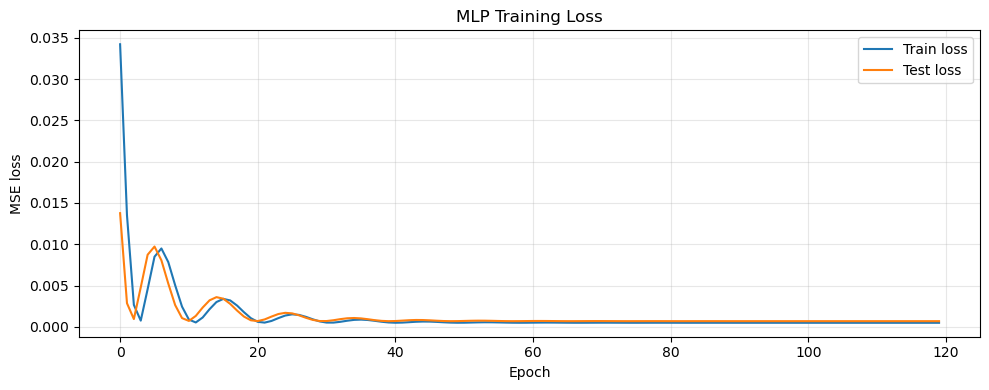

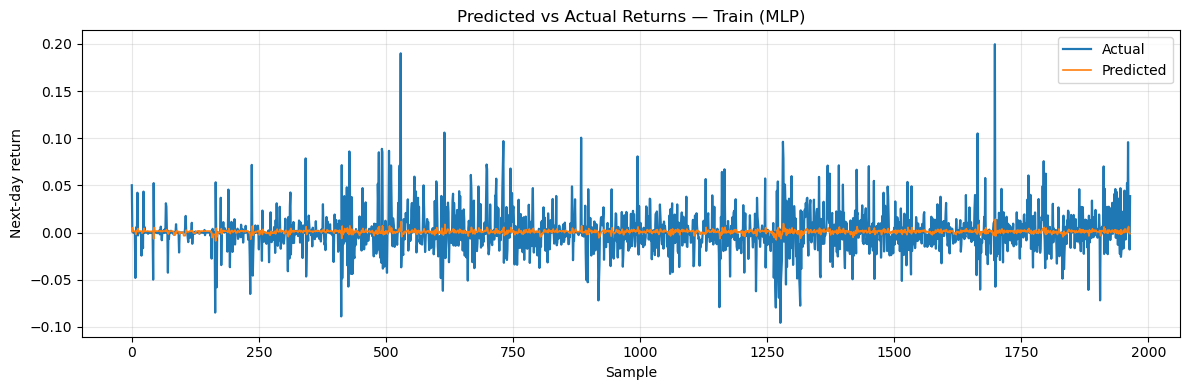

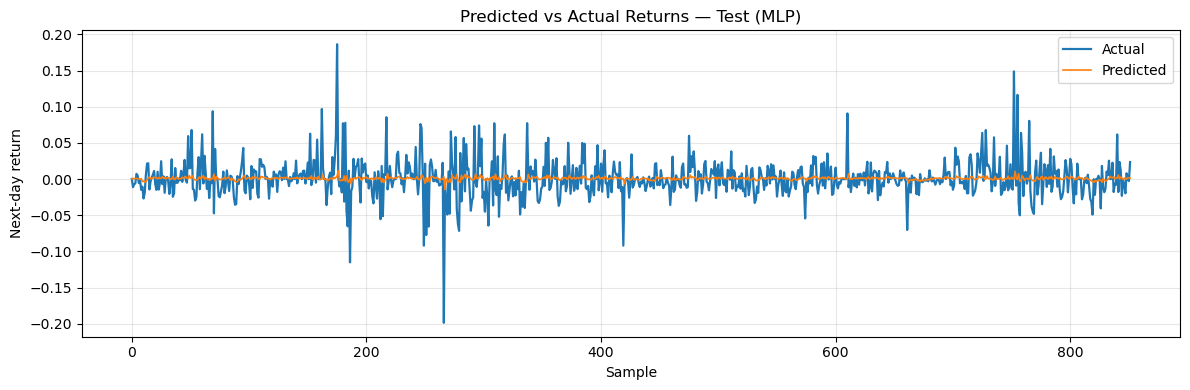

In [196]:
plot_loss(mlp_history, "MLP Training Loss")
plot_predictions(y_train, mlp_train_pred, "Predicted vs Actual Returns — Train (MLP)")
plot_predictions(y_test, mlp_test_pred, "Predicted vs Actual Returns — Test (MLP)")


## Day 2 Model: LSTM

This version keeps the same data and optimization setup, but feeds the model a chronological five-step window of features. The Week 2 helper `LSTMRegressor` uses one `nn.LSTM(..., batch_first=True)` layer and a linear head on the final sequence step.


In [197]:
set_seed(seed)
lstm = LSTMRegressor(n_features=len(FEATURE_NAMES), hidden=hidden)
lstm_history = train_model(lstm, X_train_seq, y_train_seq, X_test_seq, y_test_seq, epochs=epochs, lr=lr)

lstm_train_pred = predict(lstm, X_train_seq)
lstm_test_pred = predict(lstm, X_test_seq)

assert np.isfinite(lstm_train_pred).all()
assert np.isfinite(lstm_test_pred).all()

lstm_results = {
    "train_mse": mse(y_train_seq, lstm_train_pred),
    "test_mse": mse(y_test_seq, lstm_test_pred),
    "test_directional_accuracy": directional_accuracy(lstm_test_pred, y_test_seq),
    "test_information_coefficient": information_coefficient(lstm_test_pred, y_test_seq),
}

print(lstm)
for key, value in lstm_results.items():
    print(f"{key}: {value:.6f}")


LSTMRegressor(
  (lstm): LSTM(5, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)
train_mse: 0.000484
test_mse: 0.000680
test_directional_accuracy: 0.465962
test_information_coefficient: 0.058309


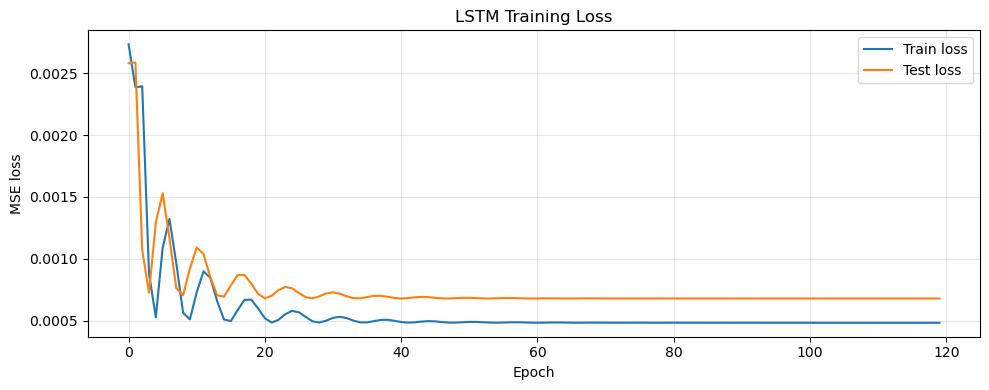

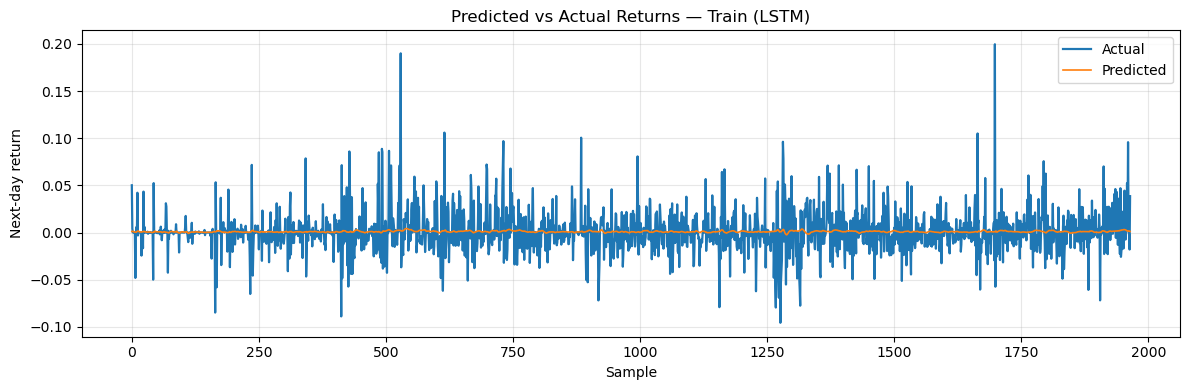

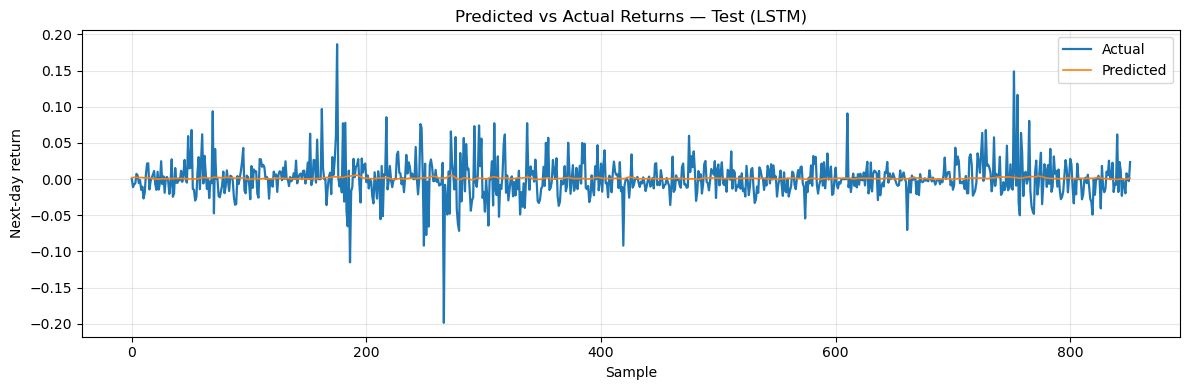

In [198]:
plot_loss(lstm_history, "LSTM Training Loss")
plot_predictions(y_train_seq, lstm_train_pred, "Predicted vs Actual Returns — Train (LSTM)")
plot_predictions(y_test_seq, lstm_test_pred, "Predicted vs Actual Returns — Test (LSTM)")


## MLP vs LSTM Comparison

| Metric | MLP | LSTM | Winner |
|---|---:|---:|---|
| Test MSE | 0.000682 | 0.000680 | LSTM |
| Directional Accuracy | 0.498826 | 0.465962 | MLP |
| Information Coefficient | 0.039615 | 0.058309 | LSTM |

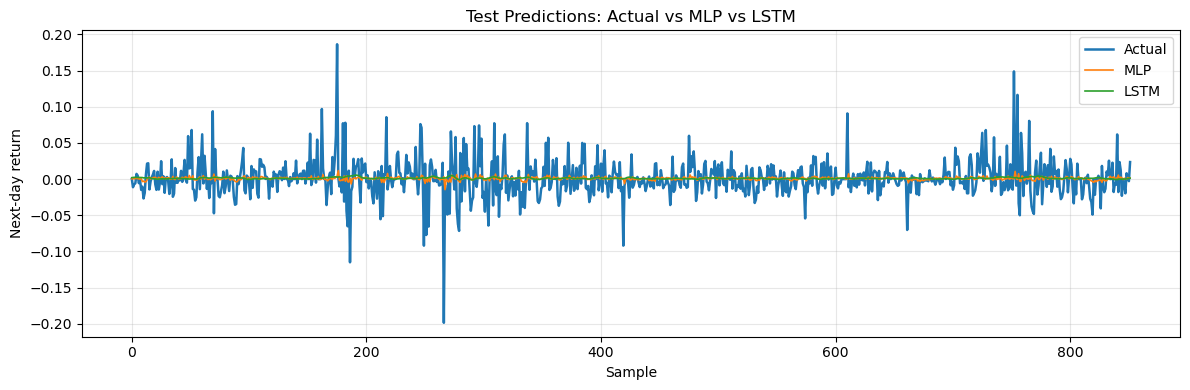

In [199]:
comparison_rows = [
    ("Test MSE", mlp_results["test_mse"], lstm_results["test_mse"], "lower"),
    (
        "Directional Accuracy",
        mlp_results["test_directional_accuracy"],
        lstm_results["test_directional_accuracy"],
        "higher",
    ),
    (
        "Information Coefficient",
        mlp_results["test_information_coefficient"],
        lstm_results["test_information_coefficient"],
        "higher",
    ),
]

lines = [
    "| Metric | MLP | LSTM | Winner |",
    "|---|---:|---:|---|",
]
for metric, mlp_value, lstm_value, better in comparison_rows:
    if np.isclose(mlp_value, lstm_value):
        winner = "Tie"
    elif better == "lower":
        winner = "MLP" if mlp_value < lstm_value else "LSTM"
    else:
        winner = "MLP" if mlp_value > lstm_value else "LSTM"
    lines.append(f"| {metric} | {mlp_value:.6f} | {lstm_value:.6f} | {winner} |")

display(Markdown("## MLP vs LSTM Comparison\n\n" + "\n".join(lines)))

plt.figure(figsize=(12, 4))
plt.plot(y_test, label="Actual", linewidth=1.8)
plt.plot(mlp_test_pred, label="MLP", linewidth=1.2)
plt.plot(lstm_test_pred, label="LSTM", linewidth=1.2)
plt.xlabel("Sample")
plt.ylabel("Next-day return")
plt.title("Test Predictions: Actual vs MLP vs LSTM")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [200]:
if (
    lstm_results["test_mse"] < mlp_results["test_mse"]
    and lstm_results["test_directional_accuracy"] >= mlp_results["test_directional_accuracy"]
    and lstm_results["test_information_coefficient"] >= mlp_results["test_information_coefficient"]
):
    answer = "Yes. The LSTM beat the MLP on the test set in this setup, so memory helped on ABUK."
elif (
    lstm_results["test_mse"] >= mlp_results["test_mse"]
    and lstm_results["test_directional_accuracy"] <= mlp_results["test_directional_accuracy"]
    and lstm_results["test_information_coefficient"] <= mlp_results["test_information_coefficient"]
):
    answer = "No. The LSTM did not beat the MLP on the test set, so adding memory did not help on ABUK in this experiment."
else:
    answer = "The result is mixed: the LSTM improved some test metrics but not all of them, so memory did not produce a clean win on ABUK."

discussion = (
    f"Both models reached very similar train MSEs "
    f"({mlp_results['train_mse']:.6f} for the MLP vs {lstm_results['train_mse']:.6f} for the LSTM), "
    f"and both still show a higher test error than train error. "
    f"Out of sample, the LSTM lowered test MSE from {mlp_results['test_mse']:.6f} to {lstm_results['test_mse']:.6f} "
    f"and improved IC from {mlp_results['test_information_coefficient']:.6f} to {lstm_results['test_information_coefficient']:.6f}, "
    f"but directional accuracy slipped from {mlp_results['test_directional_accuracy']:.6f} to {lstm_results['test_directional_accuracy']:.6f}. "
    f"That suggests the extra sequence memory helped somewhat, but not enough to dominate the simpler MLP across every Day 1 metric."
)

display(
    Markdown(
        "## Does Memory Help?\n\n"
        + answer
        + "\n\n## Train vs Test\n\n"
        + discussion
    )
)


## Does Memory Help?

The result is mixed: the LSTM improved some test metrics but not all of them, so memory did not produce a clean win on ABUK.

## Train vs Test

Both models reached very similar train MSEs (0.000485 for the MLP vs 0.000484 for the LSTM), and both still show a higher test error than train error. Out of sample, the LSTM lowered test MSE from 0.000682 to 0.000680 and improved IC from 0.039615 to 0.058309, but directional accuracy slipped from 0.498826 to 0.465962. That suggests the extra sequence memory helped somewhat, but not enough to dominate the simpler MLP across every Day 1 metric.

# ABUK Price Prediction Comparison

The MLP and LSTM in this notebook were trained to predict next-day ABUK returns rather than directly predict stock prices. To evaluate those same test predictions in price terms, we convert each predicted return into a one-step-ahead predicted closing price and compare it with the actual ABUK closing price over the same test period.

Week 2 uses simple returns, so the price conversion here is:

`predicted_price_t = actual_previous_close * (1 + predicted_return_t)`

This stays a one-step-ahead experiment because every forecast starts from the actual previous close, not from the previous predicted close.


In [201]:
from tradinglab.features import feature_columns


def mean_absolute_error(actual, predicted) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.mean(np.abs(predicted - actual)))


def root_mean_squared_error(actual, predicted) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.sqrt(np.mean((predicted - actual) ** 2)))


def mean_absolute_percentage_error(actual, predicted) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    if not np.any(mask):
        return 0.0
    return float(np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100.0)


def tolerance_accuracy(actual, predicted, tolerance_pct: float) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    if not np.any(mask):
        return 0.0
    pct_error = np.abs(predicted[mask] - actual[mask]) / actual[mask] * 100.0
    return float(np.mean(pct_error <= tolerance_pct) * 100.0)


def price_directional_accuracy(actual, predicted, previous_actual) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    previous_actual = np.asarray(previous_actual, dtype=float)
    actual_direction = np.sign(actual - previous_actual)
    predicted_direction = np.sign(predicted - previous_actual)
    return float(np.mean(actual_direction == predicted_direction) * 100.0)


def price_metrics(actual, predicted, previous_actual) -> dict[str, float]:
    mape = mean_absolute_percentage_error(actual, predicted)
    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mape": mape,
        "price_accuracy": max(0.0, 100.0 - mape),
        "within_1pct": tolerance_accuracy(actual, predicted, 1.0),
        "within_2pct": tolerance_accuracy(actual, predicted, 2.0),
        "within_5pct": tolerance_accuracy(actual, predicted, 5.0),
        "directional_accuracy": price_directional_accuracy(actual, predicted, previous_actual),
    }


abuk_close = feed.close[:, asset]
abuk_features = feature_columns(feed, asset)
abuk_target_returns = np.full(feed.n_days, np.nan)
abuk_target_returns[:-1] = feed.returns[1:, asset]

day_index = np.arange(feed.n_days)
valid_rows = ~np.isnan(abuk_features).any(axis=1) & ~np.isnan(abuk_target_returns)
full_test_feature_days = day_index[valid_rows & (day_index >= split_day)]
aligned_test_feature_days = full_test_feature_days[seq_len:]

previous_actual_test_prices = abuk_close[aligned_test_feature_days]
actual_test_prices = abuk_close[aligned_test_feature_days + 1]
test_price_dates = feed.dates[aligned_test_feature_days + 1]

assert np.allclose(y_test, abuk_target_returns[aligned_test_feature_days])
assert np.allclose(y_test, feed.returns[aligned_test_feature_days + 1, asset])
assert np.allclose(actual_test_prices, previous_actual_test_prices * (1.0 + y_test))

mlp_predicted_prices = previous_actual_test_prices * (1.0 + mlp_test_pred)
lstm_predicted_prices = previous_actual_test_prices * (1.0 + lstm_test_pred)
naive_predicted_prices = previous_actual_test_prices.copy()

assert len(actual_test_prices) == len(previous_actual_test_prices)
assert len(actual_test_prices) == len(mlp_predicted_prices)
assert len(actual_test_prices) == len(lstm_predicted_prices)
assert len(actual_test_prices) == len(naive_predicted_prices)
assert len(actual_test_prices) == len(test_price_dates)
assert np.isfinite(actual_test_prices).all()
assert np.isfinite(previous_actual_test_prices).all()
assert np.isfinite(mlp_predicted_prices).all()
assert np.isfinite(lstm_predicted_prices).all()
assert np.isfinite(naive_predicted_prices).all()

mlp_price_results = price_metrics(actual_test_prices, mlp_predicted_prices, previous_actual_test_prices)
lstm_price_results = price_metrics(actual_test_prices, lstm_predicted_prices, previous_actual_test_prices)
naive_price_results = price_metrics(actual_test_prices, naive_predicted_prices, previous_actual_test_prices)

mlp_price_accuracy = mlp_price_results["price_accuracy"]
lstm_price_accuracy = lstm_price_results["price_accuracy"]
naive_price_accuracy = naive_price_results["price_accuracy"]

print(f"Price evaluation stock: {symbol}")
print(f"Price evaluation dates: {test_price_dates[0]} -> {test_price_dates[-1]}")
print(f"Aligned test observations: {len(actual_test_prices)}")
print("Target scaling/normalization: none, so no inverse transform was needed.")
print("Return definition confirmed from DataFeed: simple return = close[t] / close[t-1] - 1")


Price evaluation stock: ABUK
Price evaluation dates: 2023-01-19 00:00:00 -> 2026-07-30 00:00:00
Aligned test observations: 852
Target scaling/normalization: none, so no inverse transform was needed.
Return definition confirmed from DataFeed: simple return = close[t] / close[t-1] - 1


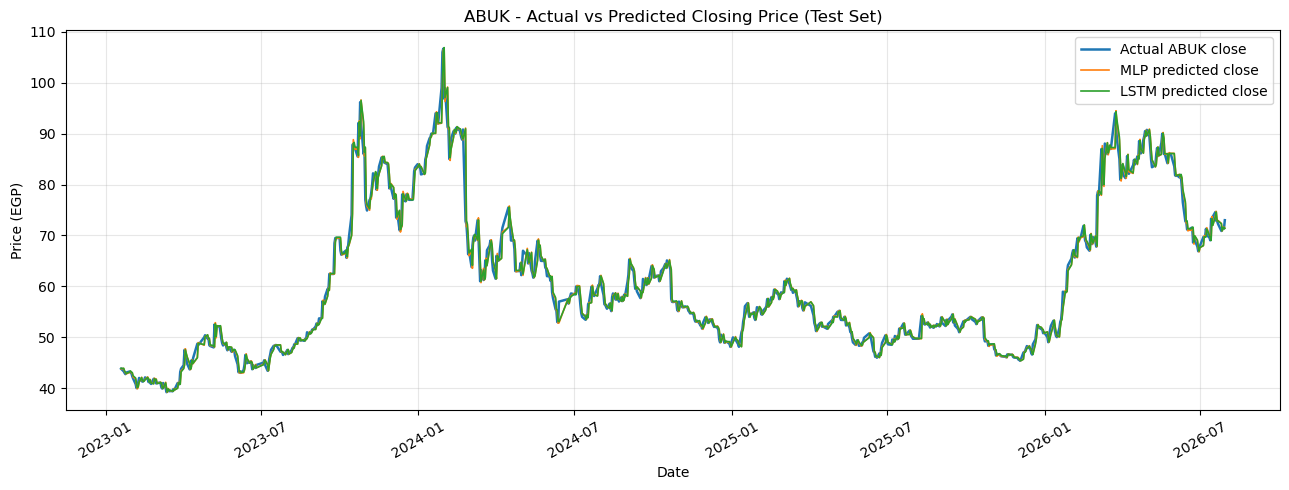

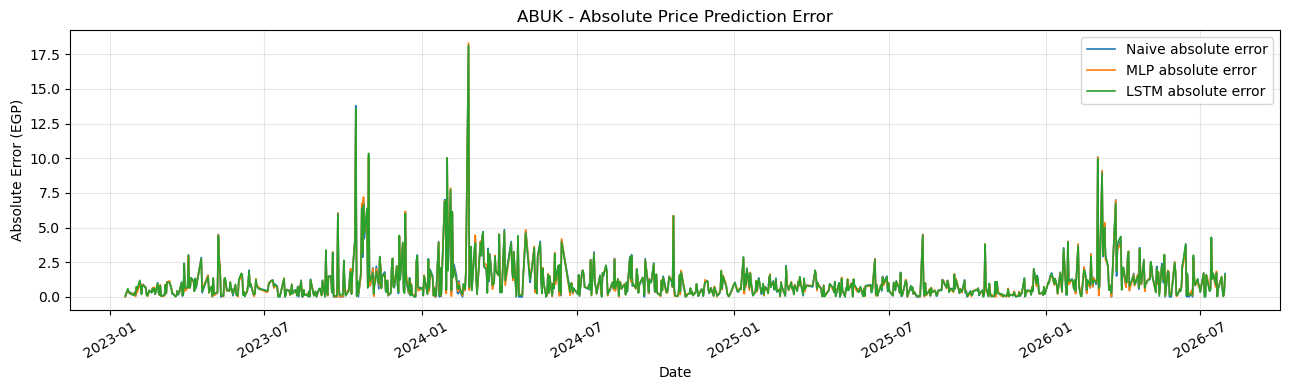

In [202]:
plt.figure(figsize=(13, 5))
plt.plot(test_price_dates, actual_test_prices, label="Actual ABUK close", linewidth=1.8)
plt.plot(test_price_dates, mlp_predicted_prices, label="MLP predicted close", linewidth=1.2)
plt.plot(test_price_dates, lstm_predicted_prices, label="LSTM predicted close", linewidth=1.2)
plt.xlabel("Date")
plt.ylabel("Price (EGP)")
plt.title("ABUK - Actual vs Predicted Closing Price (Test Set)")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 4))
plt.plot(test_price_dates, np.abs(actual_test_prices - naive_predicted_prices), label="Naive absolute error", linewidth=1.2)
plt.plot(test_price_dates, np.abs(actual_test_prices - mlp_predicted_prices), label="MLP absolute error", linewidth=1.2)
plt.plot(test_price_dates, np.abs(actual_test_prices - lstm_predicted_prices), label="LSTM absolute error", linewidth=1.2)
plt.xlabel("Date")
plt.ylabel("Absolute Error (EGP)")
plt.title("ABUK - Absolute Price Prediction Error")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [203]:
price_summary_lines = [
    "## ABUK PRICE PREDICTION - TEST SET",
    "",
    "Price accuracy (100 - MAPE) is an intuitive percentage derived from MAPE, not a classification accuracy measure.",
    "",
    "| Metric | Naive | MLP | LSTM |",
    "|---|---:|---:|---:|",
    f"| MAE (EGP) | {naive_price_results['mae']:.3f} | {mlp_price_results['mae']:.3f} | {lstm_price_results['mae']:.3f} |",
    f"| RMSE (EGP) | {naive_price_results['rmse']:.3f} | {mlp_price_results['rmse']:.3f} | {lstm_price_results['rmse']:.3f} |",
    f"| MAPE (%) | {naive_price_results['mape']:.3f}% | {mlp_price_results['mape']:.3f}% | {lstm_price_results['mape']:.3f}% |",
    f"| Price accuracy (100 - MAPE) | {naive_price_results['price_accuracy']:.3f}% | {mlp_price_results['price_accuracy']:.3f}% | {lstm_price_results['price_accuracy']:.3f}% |",
    f"| Within +/-1% | {naive_price_results['within_1pct']:.2f}% | {mlp_price_results['within_1pct']:.2f}% | {lstm_price_results['within_1pct']:.2f}% |",
    f"| Within +/-2% | {naive_price_results['within_2pct']:.2f}% | {mlp_price_results['within_2pct']:.2f}% | {lstm_price_results['within_2pct']:.2f}% |",
    f"| Within +/-5% | {naive_price_results['within_5pct']:.2f}% | {mlp_price_results['within_5pct']:.2f}% | {lstm_price_results['within_5pct']:.2f}% |",
    f"| Directional accuracy | {naive_price_results['directional_accuracy']:.2f}% | {mlp_price_results['directional_accuracy']:.2f}% | {lstm_price_results['directional_accuracy']:.2f}% |",
]
display(Markdown("\n".join(price_summary_lines)))


## ABUK PRICE PREDICTION - TEST SET

Price accuracy (100 - MAPE) is an intuitive percentage derived from MAPE, not a classification accuracy measure.

| Metric | Naive | MLP | LSTM |
|---|---:|---:|---:|
| MAE (EGP) | 1.089 | 1.100 | 1.097 |
| RMSE (EGP) | 1.842 | 1.845 | 1.843 |
| MAPE (%) | 1.699% | 1.716% | 1.713% |
| Price accuracy (100 - MAPE) | 98.301% | 98.284% | 98.287% |
| Within +/-1% | 44.72% | 45.31% | 45.07% |
| Within +/-2% | 70.89% | 70.19% | 70.77% |
| Within +/-5% | 93.54% | 93.78% | 93.31% |
| Directional accuracy | 5.05% | 49.88% | 46.60% |

In [204]:
from textwrap import dedent


def lower_is_better(metric_name: str) -> str:
    values = {
        "Naive": naive_price_results[metric_name],
        "MLP": mlp_price_results[metric_name],
        "LSTM": lstm_price_results[metric_name],
    }
    return min(values, key=values.get)


def higher_is_better(metric_name: str) -> str:
    values = {
        "Naive": naive_price_results[metric_name],
        "MLP": mlp_price_results[metric_name],
        "LSTM": lstm_price_results[metric_name],
    }
    return max(values, key=values.get)


best_mae = lower_is_better("mae")
best_rmse = lower_is_better("rmse")
best_mape = lower_is_better("mape")
best_price_accuracy = higher_is_better("price_accuracy")
best_within_1 = higher_is_better("within_1pct")
best_within_2 = higher_is_better("within_2pct")
best_within_5 = higher_is_better("within_5pct")
best_direction = higher_is_better("directional_accuracy")

if (
    lstm_price_results["mae"] < mlp_price_results["mae"]
    and lstm_price_results["rmse"] < mlp_price_results["rmse"]
    and lstm_price_results["mape"] < mlp_price_results["mape"]
):
    lstm_vs_mlp = (
        f"The LSTM improved on the MLP on the main price-error metrics "
        f"(MAE {mlp_price_results['mae']:.3f} -> {lstm_price_results['mae']:.3f}, "
        f"RMSE {mlp_price_results['rmse']:.3f} -> {lstm_price_results['rmse']:.3f}, "
        f"MAPE {mlp_price_results['mape']:.3f}% -> {lstm_price_results['mape']:.3f}%), "
        f"although the MLP kept a slightly higher directional accuracy."
    )
else:
    lstm_vs_mlp = "The LSTM did not deliver a clean improvement over the MLP across the main price metrics."

if (
    naive_price_results["mae"] <= min(mlp_price_results["mae"], lstm_price_results["mae"])
    and naive_price_results["rmse"] <= min(mlp_price_results["rmse"], lstm_price_results["rmse"])
    and naive_price_results["mape"] <= min(mlp_price_results["mape"], lstm_price_results["mape"])
    and naive_price_results["price_accuracy"] >= max(mlp_price_results["price_accuracy"], lstm_price_results["price_accuracy"])
):
    benchmark_sentence = (
        "Neither neural network beat the naive previous-close benchmark on the main price-level metrics, so neither added clear value over simply carrying forward yesterday's close."
    )
else:
    benchmark_sentence = (
        "At least one neural network beat the naive previous-close benchmark on some main price-level metrics."
    )

interpretation = f'''
## Which Model Predicted ABUK Price Best?

The lowest MAE came from **{best_mae}**, the lowest RMSE came from **{best_rmse}**, and the lowest MAPE came from **{best_mape}**. The highest price accuracy (100 - MAPE) also came from **{best_price_accuracy}**.

For tolerance accuracy, the best results were **{best_within_1}** within +/-1%, **{best_within_2}** within +/-2%, and **{best_within_5}** within +/-5%. The highest directional accuracy came from **{best_direction}**.

The MLP stayed numerically close to the real ABUK close on many days, with a test MAPE of {mlp_price_results['mape']:.3f}% and price accuracy of {mlp_price_results['price_accuracy']:.3f}%. The LSTM was similarly close, with a test MAPE of {lstm_price_results['mape']:.3f}% and price accuracy of {lstm_price_results['price_accuracy']:.3f}%.

**Was the MLP able to predict the ABUK price accurately?** In a narrow price-level sense, yes, it stayed close on average; but it did not beat the naive previous-close benchmark.

**Was the LSTM able to predict the ABUK price accurately?** Also yes in a narrow price-level sense, and it slightly improved on the MLP's MAE, RMSE, MAPE, price accuracy, and +/-1% and +/-2% hit rates; but it still did not beat the naive previous-close benchmark.

**Which model was better?** Among the two neural networks, the **LSTM** was slightly better on the main price-error metrics, while the **MLP** had a slightly better directional accuracy and +/-5% hit rate.

**Did either neural network add value over simply using yesterday's closing price?** {benchmark_sentence}

{lstm_vs_mlp}

**Interpretation warning:** a high "price accuracy" percentage does not automatically mean strong forecasting skill. Consecutive stock prices are usually close to each other, so even the naive previous-close benchmark can score very highly. That is why the neural networks should be judged against the naive benchmark, not only by how close their price lines look on the chart.
'''
display(Markdown(dedent(interpretation).strip()))


## Which Model Predicted ABUK Price Best?

The lowest MAE came from **Naive**, the lowest RMSE came from **Naive**, and the lowest MAPE came from **Naive**. The highest price accuracy (100 - MAPE) also came from **Naive**.

For tolerance accuracy, the best results were **MLP** within +/-1%, **Naive** within +/-2%, and **MLP** within +/-5%. The highest directional accuracy came from **MLP**.

The MLP stayed numerically close to the real ABUK close on many days, with a test MAPE of 1.716% and price accuracy of 98.284%. The LSTM was similarly close, with a test MAPE of 1.713% and price accuracy of 98.287%.

**Was the MLP able to predict the ABUK price accurately?** In a narrow price-level sense, yes, it stayed close on average; but it did not beat the naive previous-close benchmark.

**Was the LSTM able to predict the ABUK price accurately?** Also yes in a narrow price-level sense, and it slightly improved on the MLP's MAE, RMSE, MAPE, price accuracy, and +/-1% and +/-2% hit rates; but it still did not beat the naive previous-close benchmark.

**Which model was better?** Among the two neural networks, the **LSTM** was slightly better on the main price-error metrics, while the **MLP** had a slightly better directional accuracy and +/-5% hit rate.

**Did either neural network add value over simply using yesterday's closing price?** Neither neural network beat the naive previous-close benchmark on the main price-level metrics, so neither added clear value over simply carrying forward yesterday's close.

The LSTM improved on the MLP on the main price-error metrics (MAE 1.100 -> 1.097, RMSE 1.845 -> 1.843, MAPE 1.716% -> 1.713%), although the MLP kept a slightly higher directional accuracy.

**Interpretation warning:** a high "price accuracy" percentage does not automatically mean strong forecasting skill. Consecutive stock prices are usually close to each other, so even the naive previous-close benchmark can score very highly. That is why the neural networks should be judged against the naive benchmark, not only by how close their price lines look on the chart.

# Trading Strategy Portfolio Comparison

The neural-network section above evaluated whether the MLP and LSTM could predict ABUK returns and ABUK prices. This additional section asks a different question: how would portfolio value have evolved if historical trading decisions were made using two strategy rules that already exist elsewhere in the repository?

1. The MA9 / MA20 crossover strategy from Week 1.
2. The weekly contrarian ("TikTok") strategy from Week 1 / 05.

These are walk-forward trading-strategy backtests, not neural-network forecasts.


## SMA9 / SMA20 Portfolio

This section reuses the Week 1 MA9 / MA20 walk-forward logic on the same ABUK series already used in the Week 2 notebook. As in the source notebook, the signal is formed from the previous day, trades use the current day's close, the strategy uses whole shares only, buys with all available cash, and does not short or use leverage.


In [205]:
sma_dates = feed.dates
sma_close = feed.close[:, asset]
sma_symbol = symbol

sma_ma9 = np.full(len(sma_close), np.nan)
sma_ma20 = np.full(len(sma_close), np.nan)

for i in range(len(sma_close)):
    if i >= 8:
        sma_ma9[i] = sma_close[i - 8:i + 1].mean()
    if i >= 19:
        sma_ma20[i] = sma_close[i - 19:i + 1].mean()

sma_initial_cash = 1000.0
sma_cash = sma_initial_cash
sma_shares = 0
sma_in_position = False

sma_portfolio_values = np.zeros(len(sma_close))
sma_cash_history = np.zeros(len(sma_close))
sma_shares_history = np.zeros(len(sma_close))

sma_buy_dates = []
sma_buy_prices = []
sma_sell_dates = []
sma_sell_prices = []

sma_number_of_buys = 0
sma_number_of_sells = 0

for i in range(len(sma_close)):
    sma_current_price = sma_close[i]

    if i > 0 and not np.isnan(sma_ma9[i - 1]) and not np.isnan(sma_ma20[i - 1]):
        if sma_ma9[i - 1] > sma_ma20[i - 1] and not sma_in_position:
            sma_shares_to_buy = int(sma_cash // sma_current_price)
            if sma_shares_to_buy > 0:
                sma_cash -= sma_shares_to_buy * sma_current_price
                sma_shares = sma_shares_to_buy
                sma_buy_dates.append(sma_dates[i])
                sma_buy_prices.append(sma_current_price)
                sma_number_of_buys += 1
                sma_in_position = True
        elif sma_ma9[i - 1] < sma_ma20[i - 1] and sma_in_position:
            sma_cash += sma_shares * sma_current_price
            sma_sell_dates.append(sma_dates[i])
            sma_sell_prices.append(sma_current_price)
            sma_number_of_sells += 1
            sma_shares = 0
            sma_in_position = False

    sma_portfolio_value = sma_cash + sma_shares * sma_current_price
    sma_portfolio_values[i] = sma_portfolio_value
    sma_cash_history[i] = sma_cash
    sma_shares_history[i] = sma_shares

sma_final_portfolio_value = float(sma_portfolio_values[-1])
sma_final_cash = float(sma_cash)
sma_final_shares = int(sma_shares)
sma_profit_loss = sma_final_portfolio_value - sma_initial_cash
sma_total_return_pct = sma_profit_loss / sma_initial_cash * 100.0

sma_max_drawdown_egp = 0.0
sma_max_drawdown_pct = 0.0
sma_running_peak = sma_initial_cash

for value in sma_portfolio_values:
    if value > sma_running_peak:
        sma_running_peak = value

    sma_drawdown_egp = sma_running_peak - value
    if sma_drawdown_egp > sma_max_drawdown_egp:
        sma_max_drawdown_egp = float(sma_drawdown_egp)
        sma_max_drawdown_pct = float(sma_drawdown_egp / sma_running_peak) if sma_running_peak > 0 else 0.0

sma_benchmark_shares = int(sma_initial_cash // sma_close[0])
sma_benchmark_cash = sma_initial_cash - sma_benchmark_shares * sma_close[0]
sma_benchmark_values = sma_benchmark_cash + sma_benchmark_shares * sma_close
sma_benchmark_final_value = float(sma_benchmark_values[-1])
sma_benchmark_profit_loss = sma_benchmark_final_value - sma_initial_cash
sma_benchmark_total_return_pct = sma_benchmark_profit_loss / sma_initial_cash * 100.0
sma_excess_return_pct = sma_total_return_pct - sma_benchmark_total_return_pct

assert len(sma_ma9) == len(sma_close)
assert len(sma_ma20) == len(sma_close)
assert len(sma_portfolio_values) == len(sma_close)
assert np.all(sma_shares_history >= -1e-9)
assert np.all(sma_cash_history >= -1e-9)
assert np.isfinite(sma_final_portfolio_value)
assert not np.isnan(sma_portfolio_values).any()
assert sma_initial_cash == 1000.0

sma_summary_lines = [
    "### SMA Strategy Summary",
    "",
    f"- Stock: `{sma_symbol}`",
    f"- Date range: `{sma_dates[0]}` to `{sma_dates[-1]}`",
    f"- Starting portfolio value: `{sma_initial_cash:.2f}` EGP",
    f"- Final portfolio value: `{sma_final_portfolio_value:.2f}` EGP",
    f"- Profit / loss: `{sma_profit_loss:.2f}` EGP",
    f"- Total return: `{sma_total_return_pct:.2f}%`",
    f"- Maximum drawdown: `{sma_max_drawdown_egp:.2f}` EGP (`{sma_max_drawdown_pct * 100:.2f}%`)",
    f"- Buy operations: `{sma_number_of_buys}`",
    f"- Sell operations: `{sma_number_of_sells}`",
    f"- Final cash: `{sma_final_cash:.2f}` EGP",
    f"- Final shares held: `{sma_final_shares}`",
]
display(Markdown("\n".join(sma_summary_lines)))


### SMA Strategy Summary

- Stock: `ABUK`
- Date range: `2015-01-04 00:00:00` to `2026-07-30 00:00:00`
- Starting portfolio value: `1000.00` EGP
- Final portfolio value: `5891.18` EGP
- Profit / loss: `4891.18` EGP
- Total return: `489.12%`
- Maximum drawdown: `2326.32` EGP (`39.96%`)
- Buy operations: `83`
- Sell operations: `82`
- Final cash: `51.18` EGP
- Final shares held: `80`

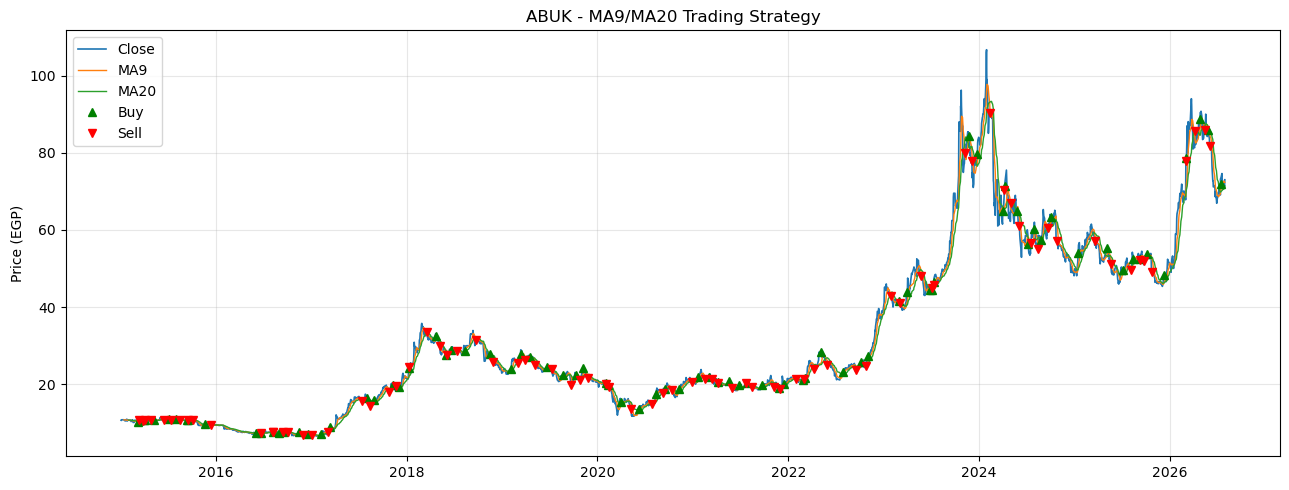

In [206]:
plt.figure(figsize=(13, 5))
plt.plot(sma_dates, sma_close, label="Close", linewidth=1.2)
plt.plot(sma_dates, sma_ma9, label="MA9", linewidth=1.0)
plt.plot(sma_dates, sma_ma20, label="MA20", linewidth=1.0)
if sma_buy_dates:
    plt.plot(sma_buy_dates, sma_buy_prices, marker="^", linestyle="None", color="green", label="Buy")
if sma_sell_dates:
    plt.plot(sma_sell_dates, sma_sell_prices, marker="v", linestyle="None", color="red", label="Sell")
plt.title(f"{sma_symbol} - MA9/MA20 Trading Strategy")
plt.ylabel("Price (EGP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


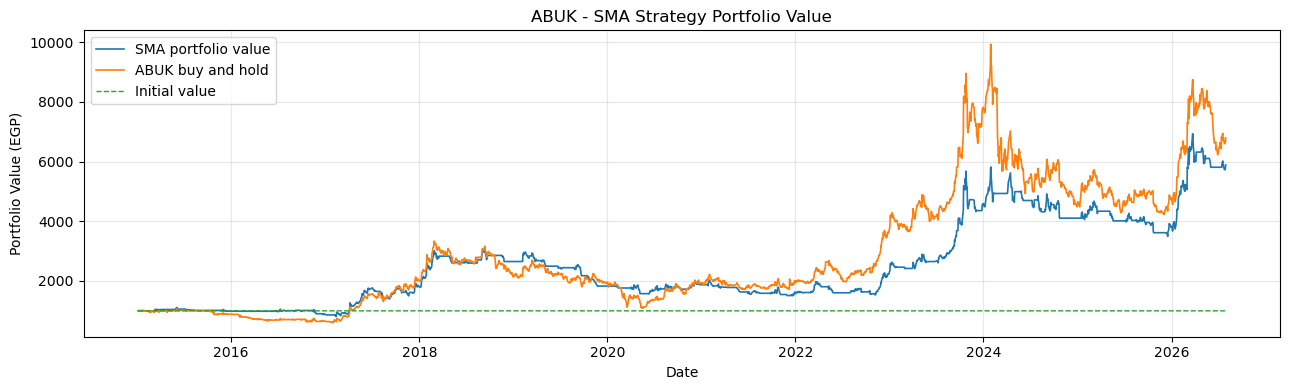

In [207]:
plt.figure(figsize=(13, 4))
plt.plot(sma_dates, sma_portfolio_values, label="SMA portfolio value", linewidth=1.2)
plt.plot(sma_dates, sma_benchmark_values, label="ABUK buy and hold", linewidth=1.2)
plt.plot(sma_dates, np.full(len(sma_dates), sma_initial_cash), label="Initial value", linestyle="--", linewidth=1.0)
plt.title(f"{sma_symbol} - SMA Strategy Portfolio Value")
plt.ylabel("Portfolio Value (EGP)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [208]:
sma_vs_hold_answer = "Yes" if sma_final_portfolio_value > sma_benchmark_final_value else "No"
sma_vs_hold_lines = [
    "### Did the SMA strategy outperform simply buying and holding ABUK?",
    "",
    f"- SMA final value: `{sma_final_portfolio_value:.2f}` EGP",
    f"- Buy-and-hold final value: `{sma_benchmark_final_value:.2f}` EGP",
    f"- SMA total return: `{sma_total_return_pct:.2f}%`",
    f"- Buy-and-hold total return: `{sma_benchmark_total_return_pct:.2f}%`",
    f"- SMA excess return: `{sma_excess_return_pct:.2f}` percentage points",
    f"- Outperformed buy and hold: **{sma_vs_hold_answer}**",
]
display(Markdown("\n".join(sma_vs_hold_lines)))


### Did the SMA strategy outperform simply buying and holding ABUK?

- SMA final value: `5891.18` EGP
- Buy-and-hold final value: `6797.00` EGP
- SMA total return: `489.12%`
- Buy-and-hold total return: `579.70%`
- SMA excess return: `-90.58` percentage points
- Outperformed buy and hold: **No**

## Weekly Contrarian ("TikTok") Portfolio

This section reuses the exact Week 1 / 05 walk-forward weekly contrarian logic. The source notebook applies it across the full EGX universe bundled with the repository, not only to ABUK. That means the SMA section below is an ABUK-only strategy, while the TikTok section is a full-universe portfolio strategy, so their raw EGP values come from different portfolio constructions.


In [209]:
tiktok_feed = DataFeed.from_dir(str(data_dir))
tiktok_dates = tiktok_feed.dates
tiktok_symbols = tiktok_feed.symbols
tiktok_close = tiktok_feed.close
tiktok_n_days = tiktok_feed.n_days
tiktok_n_stocks = tiktok_feed.n_assets

tiktok_initial_cash = 1000.0
tiktok_lookback_days = 5
tiktok_buy_threshold = -0.05
tiktok_sell_threshold = 0.10
tiktok_buy_notional = 5.0
tiktok_sell_notional = 10.0

tiktok_weekly_signals = np.full_like(tiktok_close, fill_value=np.nan, dtype=float)

for t in range(tiktok_n_days):
    tiktok_idx_recent = t - 1
    tiktok_idx_earlier = t - 1 - tiktok_lookback_days
    if tiktok_idx_recent < 0 or tiktok_idx_earlier < 0:
        continue
    tiktok_recent = tiktok_close[tiktok_idx_recent]
    tiktok_earlier = tiktok_close[tiktok_idx_earlier]
    for j in range(tiktok_n_stocks):
        tiktok_p_recent = tiktok_recent[j]
        tiktok_p_earlier = tiktok_earlier[j]
        if (not np.isfinite(tiktok_p_recent)) or (not np.isfinite(tiktok_p_earlier)):
            tiktok_weekly_signals[t, j] = np.nan
            continue
        if tiktok_p_recent <= 0 or tiktok_p_earlier <= 0:
            tiktok_weekly_signals[t, j] = np.nan
            continue
        tiktok_weekly_signals[t, j] = tiktok_p_recent / tiktok_p_earlier - 1.0

tiktok_cash = float(tiktok_initial_cash)
tiktok_holdings = np.zeros(tiktok_n_stocks, dtype=float)
tiktok_latest_valid_price = np.full(tiktok_n_stocks, np.nan, dtype=float)

tiktok_portfolio_values = np.full(tiktok_n_days, np.nan, dtype=float)
tiktok_cash_history = np.full(tiktok_n_days, np.nan, dtype=float)
tiktok_invested_value_history = np.full(tiktok_n_days, np.nan, dtype=float)
tiktok_n_positions_history = np.full(tiktok_n_days, 0, dtype=int)
tiktok_daily_buy_operations = np.zeros(tiktok_n_days, dtype=int)
tiktok_daily_sell_operations = np.zeros(tiktok_n_days, dtype=int)

tiktok_total_buy_operations = 0
tiktok_total_sell_operations = 0
tiktok_skipped_buy_operations = 0
tiktok_trade_log = []
tiktok_eps = 1e-12

for t in range(tiktok_n_days):
    tiktok_today_price = tiktok_close[t]
    tiktok_signal = tiktok_weekly_signals[t]

    for j in range(tiktok_n_stocks):
        tiktok_p = tiktok_today_price[j]
        if np.isfinite(tiktok_p) and tiktok_p > 0:
            tiktok_latest_valid_price[j] = tiktok_p

    tiktok_sells_today = 0
    for j in range(tiktok_n_stocks):
        tiktok_sig = tiktok_signal[j]
        tiktok_p = tiktok_today_price[j]
        if not (np.isfinite(tiktok_sig) and np.isfinite(tiktok_p) and tiktok_p > 0):
            continue
        if tiktok_sig >= tiktok_sell_threshold and tiktok_holdings[j] > 0:
            tiktok_position_value = tiktok_holdings[j] * tiktok_p
            tiktok_actual_sell_value = min(tiktok_sell_notional, tiktok_position_value)
            if tiktok_actual_sell_value <= tiktok_eps:
                continue
            tiktok_shares_to_sell = tiktok_actual_sell_value / tiktok_p
            tiktok_shares_to_sell = min(tiktok_shares_to_sell, tiktok_holdings[j])
            tiktok_holdings[j] -= tiktok_shares_to_sell
            tiktok_cash += tiktok_actual_sell_value
            tiktok_sells_today += 1
            tiktok_total_sell_operations += 1
            tiktok_trade_log.append({
                "date": str(tiktok_dates[t]),
                "symbol": tiktok_symbols[j],
                "operation": "SELL",
                "signal_return": float(tiktok_sig),
                "price": float(tiktok_p),
                "notional": float(tiktok_actual_sell_value),
                "shares": float(tiktok_shares_to_sell),
                "cash_after": float(tiktok_cash),
                "position_shares_after": float(tiktok_holdings[j]),
            })

    tiktok_daily_sell_operations[t] = tiktok_sells_today

    tiktok_buys_today = 0
    for j in range(tiktok_n_stocks):
        tiktok_sig = tiktok_signal[j]
        tiktok_p = tiktok_today_price[j]
        if not (np.isfinite(tiktok_sig) and np.isfinite(tiktok_p) and tiktok_p > 0):
            continue
        if tiktok_sig <= tiktok_buy_threshold:
            tiktok_actual_buy_value = min(tiktok_buy_notional, tiktok_cash)
            if tiktok_actual_buy_value <= tiktok_eps:
                tiktok_skipped_buy_operations += 1
                continue
            tiktok_shares_to_buy = tiktok_actual_buy_value / tiktok_p
            tiktok_holdings[j] += tiktok_shares_to_buy
            tiktok_cash -= tiktok_actual_buy_value
            tiktok_buys_today += 1
            tiktok_total_buy_operations += 1
            tiktok_trade_log.append({
                "date": str(tiktok_dates[t]),
                "symbol": tiktok_symbols[j],
                "operation": "BUY",
                "signal_return": float(tiktok_sig),
                "price": float(tiktok_p),
                "notional": float(tiktok_actual_buy_value),
                "shares": float(tiktok_shares_to_buy),
                "cash_after": float(tiktok_cash),
                "position_shares_after": float(tiktok_holdings[j]),
            })

    tiktok_daily_buy_operations[t] = tiktok_buys_today

    tiktok_invested = 0.0
    tiktok_n_positions = 0
    for j in range(tiktok_n_stocks):
        if tiktok_holdings[j] > 0:
            tiktok_p_val = tiktok_latest_valid_price[j]
            if np.isfinite(tiktok_p_val) and tiktok_p_val > 0:
                tiktok_invested += tiktok_holdings[j] * tiktok_p_val
                tiktok_n_positions += 1

    tiktok_portfolio_value = tiktok_cash + tiktok_invested
    if not np.isfinite(tiktok_portfolio_value) or tiktok_portfolio_value < 0:
        tiktok_portfolio_value = float(tiktok_cash) + float(max(0.0, tiktok_invested))

    tiktok_portfolio_values[t] = tiktok_portfolio_value
    tiktok_cash_history[t] = tiktok_cash
    tiktok_invested_value_history[t] = tiktok_invested
    tiktok_n_positions_history[t] = tiktok_n_positions

tiktok_valid_idx = np.isfinite(tiktok_portfolio_values)
tiktok_final_portfolio_value = float(tiktok_portfolio_values[tiktok_valid_idx][-1])
tiktok_profit_loss = tiktok_final_portfolio_value - tiktok_initial_cash
tiktok_total_return_pct = tiktok_profit_loss / tiktok_initial_cash * 100.0

tiktok_running_peak = np.maximum.accumulate(np.where(tiktok_valid_idx, tiktok_portfolio_values, -np.inf))
tiktok_first_valid = int(np.argmax(tiktok_valid_idx))
tiktok_running_peak[:tiktok_first_valid] = tiktok_portfolio_values[tiktok_first_valid]
tiktok_drawdown_egp = tiktok_running_peak - np.where(tiktok_valid_idx, tiktok_portfolio_values, tiktok_running_peak)
with np.errstate(divide="ignore", invalid="ignore"):
    tiktok_drawdown_pct = np.where(tiktok_running_peak > 0, tiktok_drawdown_egp / tiktok_running_peak * 100.0, 0.0)
tiktok_max_drawdown_egp = float(np.nanmax(tiktok_drawdown_egp))
tiktok_max_drawdown_pct = float(np.nanmax(tiktok_drawdown_pct))

tiktok_final_cash = float(tiktok_cash_history[tiktok_valid_idx][-1])
tiktok_final_invested_value = float(tiktok_invested_value_history[tiktok_valid_idx][-1])
tiktok_open_positions_at_end = int((tiktok_holdings > 0).sum())
tiktok_unique_traded = len(set([trade["symbol"] for trade in tiktok_trade_log]))
tiktok_benchmark_values = None

assert tiktok_initial_cash == 1000.0
assert tiktok_close.ndim == 2
assert tiktok_close.shape[0] == tiktok_n_days
assert tiktok_close.shape[1] == tiktok_n_stocks
assert np.isnan(tiktok_weekly_signals[:tiktok_lookback_days + 1]).all()
assert np.isfinite(tiktok_portfolio_values).all()
assert np.all(tiktok_cash_history >= -1e-9)
assert np.all(tiktok_holdings >= -1e-9)
assert np.all(tiktok_n_positions_history >= 0)
assert len(tiktok_portfolio_values) == len(tiktok_dates)
assert not np.isnan(tiktok_portfolio_values).any()

tiktok_summary_lines = [
    "### TikTok Strategy Summary",
    "",
    f"- Universe: full EGX universe from the Week 1 / 05 notebook (`{tiktok_n_stocks}` stocks)",
    f"- Date range: `{tiktok_dates[0]}` to `{tiktok_dates[-1]}`",
    f"- Starting portfolio value: `{tiktok_initial_cash:.2f}` EGP",
    f"- Final portfolio value: `{tiktok_final_portfolio_value:.2f}` EGP",
    f"- Profit / loss: `{tiktok_profit_loss:.2f}` EGP",
    f"- Total return: `{tiktok_total_return_pct:.2f}%`",
    f"- Maximum drawdown: `{tiktok_max_drawdown_egp:.2f}` EGP (`{tiktok_max_drawdown_pct:.2f}%`)",
    f"- Buy operations: `{tiktok_total_buy_operations}`",
    f"- Sell operations: `{tiktok_total_sell_operations}`",
    f"- Open positions at the end: `{tiktok_open_positions_at_end}`",
    f"- Final cash: `{tiktok_final_cash:.2f}` EGP",
    f"- Final invested value: `{tiktok_final_invested_value:.2f}` EGP",
    f"- Unique stocks traded: `{tiktok_unique_traded}`",
    f"- Skipped buy operations due to insufficient cash: `{tiktok_skipped_buy_operations}`",
]
display(Markdown("\n".join(tiktok_summary_lines)))


### TikTok Strategy Summary

- Universe: full EGX universe from the Week 1 / 05 notebook (`34` stocks)
- Date range: `2021-10-20 00:00:00` to `2026-07-30 00:00:00`
- Starting portfolio value: `1000.00` EGP
- Final portfolio value: `4233.30` EGP
- Profit / loss: `3233.30` EGP
- Total return: `323.33%`
- Maximum drawdown: `507.20` EGP (`26.20%`)
- Buy operations: `3847`
- Sell operations: `1946`
- Open positions at the end: `32`
- Final cash: `204.72` EGP
- Final invested value: `4028.58` EGP
- Unique stocks traded: `33`
- Skipped buy operations due to insufficient cash: `1023`

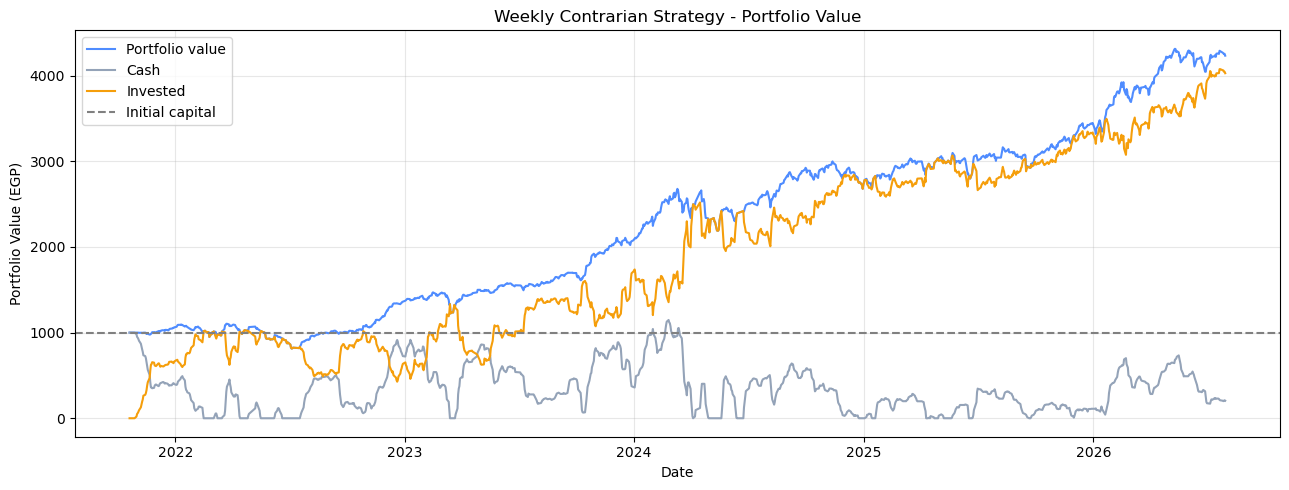

In [210]:
plt.figure(figsize=(13, 5))
plt.plot(tiktok_dates, tiktok_portfolio_values, label="Portfolio value", color="#4f8cff")
plt.plot(tiktok_dates, tiktok_cash_history, label="Cash", color="#94a3b8")
plt.plot(tiktok_dates, tiktok_invested_value_history, label="Invested", color="#f59e0b")
plt.axhline(tiktok_initial_cash, color="gray", linestyle="--", label="Initial capital")
plt.title("Weekly Contrarian Strategy - Portfolio Value")
plt.ylabel("Portfolio Value (EGP)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Strategy Comparison

The SMA strategy uses only ABUK and spans the full ABUK-only feed from 2015-01-04 to 2026-07-30. The TikTok strategy keeps the full-universe Week 1 / 05 setup, so it uses the common-date EGX universe window from 2021-10-20 to 2026-07-30. Because the strategies operate on different universes and different historical windows, raw EGP values are not a clean apples-to-apples comparison. The plot below therefore normalizes each strategy to the growth of its own initial 1,000 EGP.

The Week 1 / 05 TikTok notebook does not define a benchmark portfolio, so the benchmark shown below is the ABUK buy-and-hold benchmark that is directly relevant to the SMA strategy.


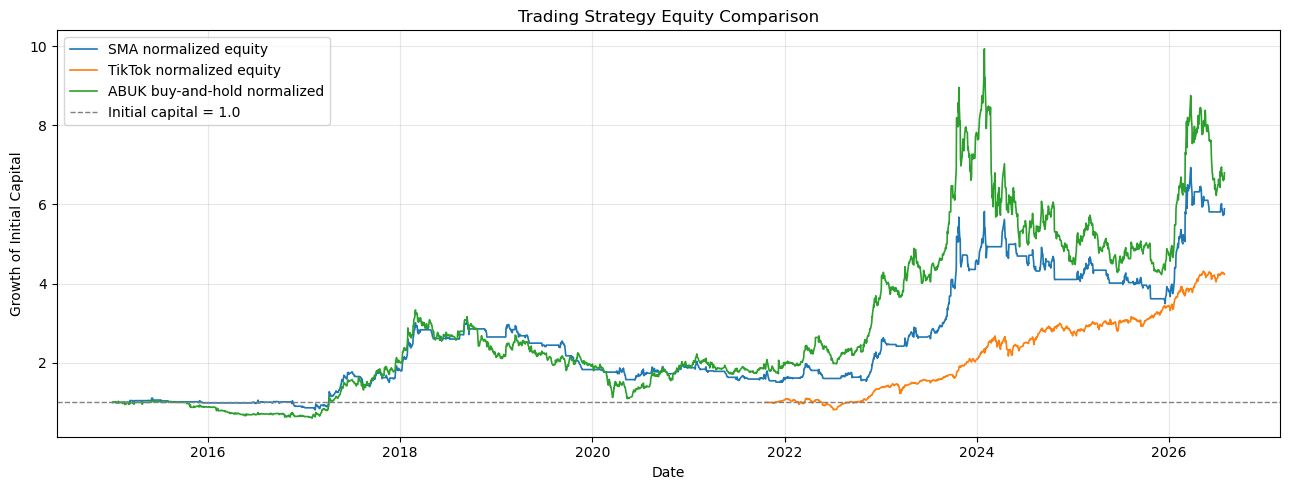

## PORTFOLIO STRATEGY SUMMARY

| Metric | SMA Strategy | TikTok Strategy |
|---|---:|---:|
| Universe | ABUK | Full EGX universe |
| Start date | 2015-01-04 | 2021-10-20 |
| End date | 2026-07-30 | 2026-07-30 |
| Initial value (EGP) | 1000.00 | 1000.00 |
| Final value (EGP) | 5891.18 | 4233.30 |
| Profit / loss (EGP) | 4891.18 | 3233.30 |
| Total return (%) | 489.12% | 323.33% |
| Maximum drawdown (%) | 39.96% | 26.20% |
| Buy operations | 83 | 3847 |
| Sell operations | 82 | 1946 |

- TikTok open positions at the end: `32`
- Higher normalized growth over each strategy's own source-notebook window: **SMA strategy**

In [211]:
sma_normalized_values = sma_portfolio_values / sma_initial_cash
sma_benchmark_normalized = sma_benchmark_values / sma_initial_cash
tiktok_normalized_values = tiktok_portfolio_values / tiktok_initial_cash

assert np.isfinite(sma_normalized_values).all()
assert np.isfinite(sma_benchmark_normalized).all()
assert np.isfinite(tiktok_normalized_values).all()

plt.figure(figsize=(13, 5))
plt.plot(sma_dates, sma_normalized_values, label="SMA normalized equity", linewidth=1.2)
plt.plot(tiktok_dates, tiktok_normalized_values, label="TikTok normalized equity", linewidth=1.2)
plt.plot(sma_dates, sma_benchmark_normalized, label="ABUK buy-and-hold normalized", linewidth=1.2)
plt.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="Initial capital = 1.0")
plt.title("Trading Strategy Equity Comparison")
plt.ylabel("Growth of Initial Capital")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

higher_normalized_growth = "SMA strategy" if sma_normalized_values[-1] > tiktok_normalized_values[-1] else "TikTok strategy"

comparison_lines = [
    "## PORTFOLIO STRATEGY SUMMARY",
    "",
    "| Metric | SMA Strategy | TikTok Strategy |",
    "|---|---:|---:|",
    f"| Universe | ABUK | Full EGX universe |",
    f"| Start date | {sma_dates[0].date()} | {tiktok_dates[0].date()} |",
    f"| End date | {sma_dates[-1].date()} | {tiktok_dates[-1].date()} |",
    f"| Initial value (EGP) | {sma_initial_cash:.2f} | {tiktok_initial_cash:.2f} |",
    f"| Final value (EGP) | {sma_final_portfolio_value:.2f} | {tiktok_final_portfolio_value:.2f} |",
    f"| Profit / loss (EGP) | {sma_profit_loss:.2f} | {tiktok_profit_loss:.2f} |",
    f"| Total return (%) | {sma_total_return_pct:.2f}% | {tiktok_total_return_pct:.2f}% |",
    f"| Maximum drawdown (%) | {sma_max_drawdown_pct * 100:.2f}% | {tiktok_max_drawdown_pct:.2f}% |",
    f"| Buy operations | {sma_number_of_buys} | {tiktok_total_buy_operations} |",
    f"| Sell operations | {sma_number_of_sells} | {tiktok_total_sell_operations} |",
]
comparison_lines.extend([
    "",
    f"- TikTok open positions at the end: `{tiktok_open_positions_at_end}`",
    f"- Higher normalized growth over each strategy's own source-notebook window: **{higher_normalized_growth}**",
])
display(Markdown("\n".join(comparison_lines)))


## Strategy Results vs Prediction Results

The MLP and LSTM sections above evaluate forecast accuracy. The SMA and TikTok sections evaluate the financial result of explicit trading rules. High prediction accuracy does not automatically imply high portfolio returns, and a profitable trading rule does not necessarily imply accurate price forecasting.


In [212]:
sma_beat_buy_hold = sma_final_portfolio_value > sma_benchmark_final_value
interpretation_lines = [
    "## Interpretation",
    "",
    f"- The SMA strategy finished at `{sma_final_portfolio_value:.2f}` EGP, while ABUK buy-and-hold finished at `{sma_benchmark_final_value:.2f}` EGP.",
    f"- The SMA strategy {'did' if sma_beat_buy_hold else 'did not'} outperform buying and holding ABUK. Its excess return was `{sma_excess_return_pct:.2f}` percentage points.",
    f"- The TikTok strategy finished at `{tiktok_final_portfolio_value:.2f}` EGP on the full-universe Week 1 / 05 setup, with `{tiktok_open_positions_at_end}` open positions remaining at the end.",
    f"- On normalized growth over each strategy's own source-notebook window, the {'SMA strategy' if sma_normalized_values[-1] > tiktok_normalized_values[-1] else 'TikTok strategy'} ended higher.",
    "- Because the SMA strategy uses one stock and the TikTok strategy uses the full EGX universe over a shorter shared-date window, the normalized plot is the most honest visual comparison here.",
]
display(Markdown("\n".join(interpretation_lines)))


## Interpretation

- The SMA strategy finished at `5891.18` EGP, while ABUK buy-and-hold finished at `6797.00` EGP.
- The SMA strategy did not outperform buying and holding ABUK. Its excess return was `-90.58` percentage points.
- The TikTok strategy finished at `4233.30` EGP on the full-universe Week 1 / 05 setup, with `32` open positions remaining at the end.
- On normalized growth over each strategy's own source-notebook window, the SMA strategy ended higher.
- Because the SMA strategy uses one stock and the TikTok strategy uses the full EGX universe over a shorter shared-date window, the normalized plot is the most honest visual comparison here.

# Model Signal Portfolio Comparison

This section keeps the earlier Day 2 forecast outputs fixed and asks a new question: what happens if the already-computed MLP and LSTM return predictions are used as simple long-or-cash ABUK trading signals during the **test period only**?

The earlier notebook cells already established the relevant timing:

- the target is the **next-day simple return**
- the MLP baseline was trimmed to match the LSTM warm-up offset
- `y_test`, `mlp_test_pred`, `lstm_test_pred`, and `test_price_dates` are already aligned to the same test observations

So the rule below is:

- if predicted return `> 0`: invest in ABUK for that period
- if predicted return `<= 0`: stay in cash

Predicted returns decide **whether** the portfolio is invested. Realized profit and loss come only from the **actual** ABUK return for that forecast period.


In [213]:
common_test_dates = test_price_dates
common_test_dates_plot = test_price_dates.to_pydatetime() if hasattr(test_price_dates, "to_pydatetime") else np.asarray(test_price_dates, dtype=object)
common_actual_returns = y_test
common_mlp_predictions = mlp_test_pred
common_lstm_predictions = lstm_test_pred
initial_model_portfolio = 1000.0

assert len(common_test_dates) == len(common_actual_returns) == len(common_mlp_predictions) == len(common_lstm_predictions)
assert np.isfinite(common_actual_returns).all()
assert np.isfinite(common_mlp_predictions).all()
assert np.isfinite(common_lstm_predictions).all()
assert np.allclose(common_actual_returns, y_test_seq)

common_portfolio_dates = test_price_dates.insert(0, test_price_dates[0]) if hasattr(test_price_dates, "insert") else np.concatenate(([common_test_dates[0]], common_test_dates))
common_portfolio_dates_plot = common_portfolio_dates.to_pydatetime() if hasattr(common_portfolio_dates, "to_pydatetime") else np.asarray(common_portfolio_dates, dtype=object)


def count_position_changes(position_history):
    position_history = np.asarray(position_history, dtype=int)
    previous_position = np.concatenate(([0], position_history[:-1]))
    buy_operations = int(np.sum((previous_position == 0) & (position_history == 1)))
    sell_operations = int(np.sum((previous_position == 1) & (position_history == 0)))
    return buy_operations, sell_operations


def max_drawdown_pct(portfolio_values):
    portfolio_values = np.asarray(portfolio_values, dtype=float)
    running_peak = np.maximum.accumulate(portfolio_values)
    drawdowns = np.where(running_peak > 0, (portfolio_values - running_peak) / running_peak, 0.0)
    return float(-np.min(drawdowns) * 100.0)


def sharpe_ratio(daily_returns):
    daily_returns = np.asarray(daily_returns, dtype=float)
    return float(np.mean(daily_returns) / np.std(daily_returns) * np.sqrt(252)) if np.std(daily_returns) > 0 else 0.0


def run_long_or_cash_portfolio(predictions, actual_returns, initial_value=1000.0):
    predictions = np.asarray(predictions, dtype=float)
    actual_returns = np.asarray(actual_returns, dtype=float)

    portfolio_values = [float(initial_value)]
    strategy_returns = []
    position_history = []

    for prediction, actual_return in zip(predictions, actual_returns):
        invested = 1 if prediction > 0 else 0
        realized_return = float(actual_return) if invested else 0.0
        position_history.append(invested)
        strategy_returns.append(realized_return)
        portfolio_values.append(portfolio_values[-1] * (1.0 + realized_return))

    portfolio_values = np.asarray(portfolio_values, dtype=float)
    strategy_returns = np.asarray(strategy_returns, dtype=float)
    position_history = np.asarray(position_history, dtype=int)

    buy_operations, sell_operations = count_position_changes(position_history)
    exposure_pct = float(np.mean(position_history) * 100.0)
    final_value = float(portfolio_values[-1])
    profit_loss = float(final_value - initial_value)
    total_return_pct = float((final_value / initial_value - 1.0) * 100.0)

    return {
        "portfolio_values": portfolio_values,
        "strategy_returns": strategy_returns,
        "positions": position_history,
        "final_value": final_value,
        "profit_loss": profit_loss,
        "total_return_pct": total_return_pct,
        "max_drawdown_pct": max_drawdown_pct(portfolio_values),
        "buy_operations": buy_operations,
        "sell_operations": sell_operations,
        "exposure_pct": exposure_pct,
        "sharpe": sharpe_ratio(strategy_returns),
    }


mlp_portfolio = run_long_or_cash_portfolio(common_mlp_predictions, common_actual_returns, initial_value=initial_model_portfolio)
lstm_portfolio = run_long_or_cash_portfolio(common_lstm_predictions, common_actual_returns, initial_value=initial_model_portfolio)

model_buy_hold_positions = np.ones(len(common_actual_returns), dtype=int)
model_buy_hold_values = [float(initial_model_portfolio)]
for actual_return in common_actual_returns:
    model_buy_hold_values.append(model_buy_hold_values[-1] * (1.0 + float(actual_return)))
model_buy_hold_values = np.asarray(model_buy_hold_values, dtype=float)
model_buy_hold_returns = np.asarray(common_actual_returns, dtype=float)

buy_hold_portfolio = {
    "portfolio_values": model_buy_hold_values,
    "strategy_returns": model_buy_hold_returns,
    "positions": model_buy_hold_positions,
    "final_value": float(model_buy_hold_values[-1]),
    "profit_loss": float(model_buy_hold_values[-1] - initial_model_portfolio),
    "total_return_pct": float((model_buy_hold_values[-1] / initial_model_portfolio - 1.0) * 100.0),
    "max_drawdown_pct": max_drawdown_pct(model_buy_hold_values),
    "buy_operations": 1,
    "sell_operations": 0,
    "exposure_pct": 100.0,
    "sharpe": sharpe_ratio(model_buy_hold_returns),
}

mlp_portfolio_values = mlp_portfolio["portfolio_values"]
lstm_portfolio_values = lstm_portfolio["portfolio_values"]
mlp_positions = mlp_portfolio["positions"]
lstm_positions = lstm_portfolio["positions"]

mlp_buy_operations = mlp_portfolio["buy_operations"]
mlp_sell_operations = mlp_portfolio["sell_operations"]
lstm_buy_operations = lstm_portfolio["buy_operations"]
lstm_sell_operations = lstm_portfolio["sell_operations"]

mlp_exposure_pct = mlp_portfolio["exposure_pct"]
lstm_exposure_pct = lstm_portfolio["exposure_pct"]

assert common_test_dates[0] == test_price_dates[0]
assert len(mlp_portfolio_values) == len(lstm_portfolio_values) == len(model_buy_hold_values) == len(common_portfolio_dates)
assert len(mlp_positions) == len(lstm_positions) == len(common_actual_returns)
assert np.isfinite(mlp_portfolio_values).all()
assert np.isfinite(lstm_portfolio_values).all()
assert np.isfinite(model_buy_hold_values).all()
assert mlp_portfolio_values[0] == initial_model_portfolio
assert lstm_portfolio_values[0] == initial_model_portfolio
assert model_buy_hold_values[0] == initial_model_portfolio

print(f"Common test period: {common_test_dates[0]} -> {common_test_dates[-1]}")
print(f"Aligned observations: {len(common_test_dates)}")
print("Portfolio timing rule confirmed: prediction decides position, actual next-day simple return drives P&L.")


Common test period: 2023-01-19 00:00:00 -> 2026-07-30 00:00:00
Aligned observations: 852
Portfolio timing rule confirmed: prediction decides position, actual next-day simple return drives P&L.


## MLP Trading Portfolio

The MLP portfolio is invested only on test observations where the existing MLP prediction is positive.


In [214]:
mlp_summary_lines = [
    "### MLP Portfolio Summary",
    "",
    f"- Initial value: `{initial_model_portfolio:.2f}` EGP",
    f"- Final value: `{mlp_portfolio['final_value']:.2f}` EGP",
    f"- Profit / loss: `{mlp_portfolio['profit_loss']:.2f}` EGP",
    f"- Total return: `{mlp_portfolio['total_return_pct']:.2f}%`",
    f"- Maximum drawdown: `{mlp_portfolio['max_drawdown_pct']:.2f}%`",
    f"- Market exposure: `{mlp_portfolio['exposure_pct']:.2f}%`",
    f"- Buy operations: `{mlp_buy_operations}`",
    f"- Sell operations: `{mlp_sell_operations}`",
    f"- Sharpe ratio: `{mlp_portfolio['sharpe']:.2f}`",
]
display(Markdown("\n".join(mlp_summary_lines)))


### MLP Portfolio Summary

- Initial value: `1000.00` EGP
- Final value: `3371.15` EGP
- Profit / loss: `2371.15` EGP
- Total return: `237.11%`
- Maximum drawdown: `36.01%`
- Market exposure: `73.47%`
- Buy operations: `111`
- Sell operations: `110`
- Sharpe ratio: `1.20`

## LSTM Trading Portfolio

The LSTM portfolio uses the same ABUK test returns and the same long-or-cash rule, but the signal comes from the existing LSTM prediction.


In [215]:
lstm_summary_lines = [
    "### LSTM Portfolio Summary",
    "",
    f"- Initial value: `{initial_model_portfolio:.2f}` EGP",
    f"- Final value: `{lstm_portfolio['final_value']:.2f}` EGP",
    f"- Profit / loss: `{lstm_portfolio['profit_loss']:.2f}` EGP",
    f"- Total return: `{lstm_portfolio['total_return_pct']:.2f}%`",
    f"- Maximum drawdown: `{lstm_portfolio['max_drawdown_pct']:.2f}%`",
    f"- Market exposure: `{lstm_portfolio['exposure_pct']:.2f}%`",
    f"- Buy operations: `{lstm_buy_operations}`",
    f"- Sell operations: `{lstm_sell_operations}`",
    f"- Sharpe ratio: `{lstm_portfolio['sharpe']:.2f}`",
]
display(Markdown("\n".join(lstm_summary_lines)))


### LSTM Portfolio Summary

- Initial value: `1000.00` EGP
- Final value: `2272.43` EGP
- Profit / loss: `1272.43` EGP
- Total return: `127.24%`
- Maximum drawdown: `46.03%`
- Market exposure: `94.13%`
- Buy operations: `18`
- Sell operations: `17`
- Sharpe ratio: `0.80`

In [216]:
buy_hold_summary_lines = [
    "### Buy-and-Hold Benchmark Summary",
    "",
    f"- Initial value: `{initial_model_portfolio:.2f}` EGP",
    f"- Final value: `{buy_hold_portfolio['final_value']:.2f}` EGP",
    f"- Profit / loss: `{buy_hold_portfolio['profit_loss']:.2f}` EGP",
    f"- Total return: `{buy_hold_portfolio['total_return_pct']:.2f}%`",
    f"- Maximum drawdown: `{buy_hold_portfolio['max_drawdown_pct']:.2f}%`",
    f"- Market exposure: `{buy_hold_portfolio['exposure_pct']:.2f}%`",
    f"- Buy operations: `{buy_hold_portfolio['buy_operations']}`",
    f"- Sell operations: `{buy_hold_portfolio['sell_operations']}`",
    f"- Sharpe ratio: `{buy_hold_portfolio['sharpe']:.2f}`",
]
display(Markdown("\n".join(buy_hold_summary_lines)))


### Buy-and-Hold Benchmark Summary

- Initial value: `1000.00` EGP
- Final value: `1667.05` EGP
- Profit / loss: `667.05` EGP
- Total return: `66.70%`
- Maximum drawdown: `57.48%`
- Market exposure: `100.00%`
- Buy operations: `1`
- Sell operations: `0`
- Sharpe ratio: `0.57`

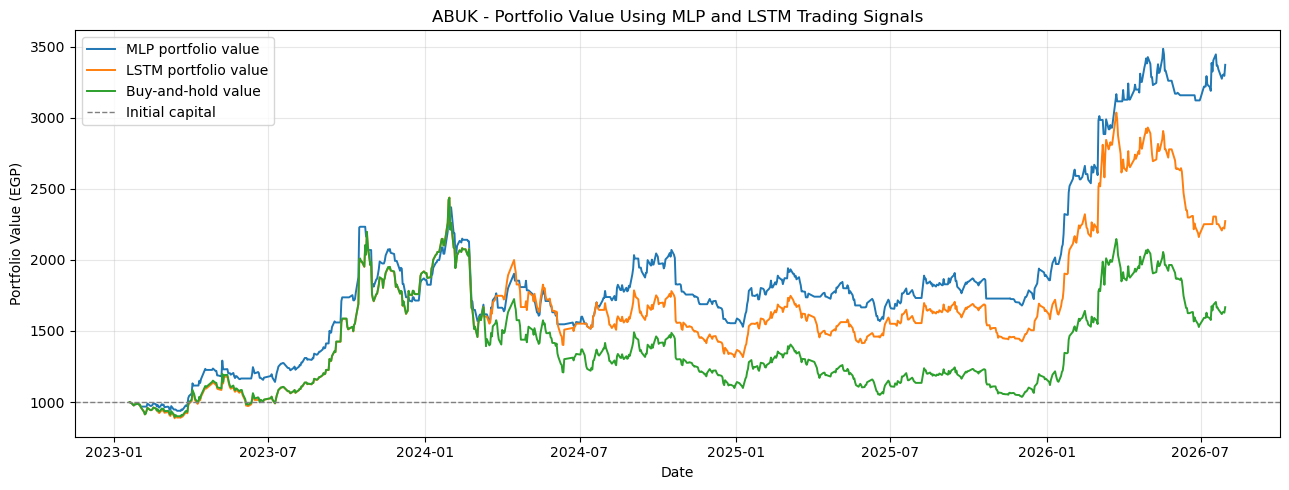

In [217]:
plt.figure(figsize=(13, 5))
plt.plot(common_portfolio_dates_plot, mlp_portfolio_values, label="MLP portfolio value", linewidth=1.4)
plt.plot(common_portfolio_dates_plot, lstm_portfolio_values, label="LSTM portfolio value", linewidth=1.4)
plt.plot(common_portfolio_dates_plot, model_buy_hold_values, label="Buy-and-hold value", linewidth=1.4)
plt.axhline(initial_model_portfolio, color="gray", linestyle="--", linewidth=1.0, label="Initial capital")
plt.title("ABUK - Portfolio Value Using MLP and LSTM Trading Signals")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (EGP)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


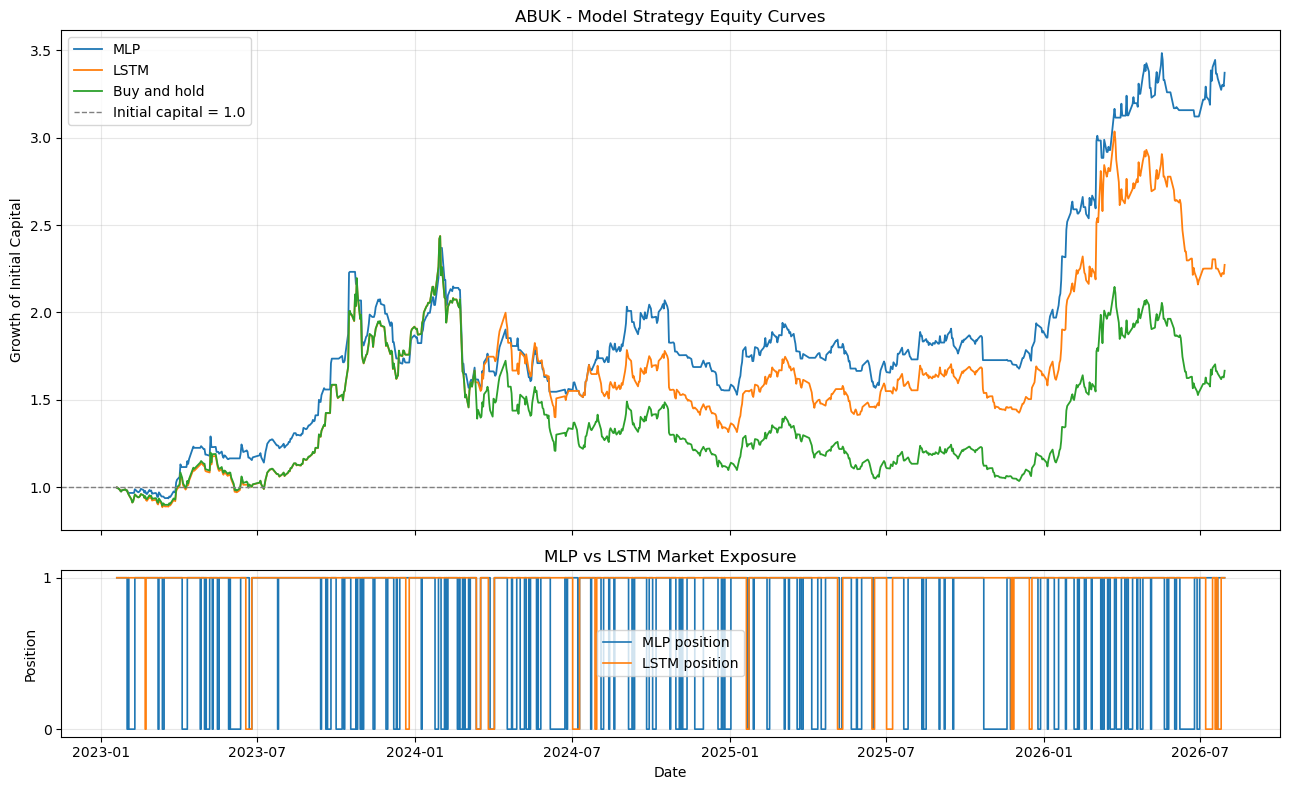

In [218]:
mlp_normalized = mlp_portfolio_values / initial_model_portfolio
lstm_normalized = lstm_portfolio_values / initial_model_portfolio
buy_hold_normalized = model_buy_hold_values / initial_model_portfolio

fig, (ax_equity, ax_position) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax_equity.plot(common_portfolio_dates_plot, mlp_normalized, label="MLP", linewidth=1.3)
ax_equity.plot(common_portfolio_dates_plot, lstm_normalized, label="LSTM", linewidth=1.3)
ax_equity.plot(common_portfolio_dates_plot, buy_hold_normalized, label="Buy and hold", linewidth=1.3)
ax_equity.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="Initial capital = 1.0")
ax_equity.set_title("ABUK - Model Strategy Equity Curves")
ax_equity.set_ylabel("Growth of Initial Capital")
ax_equity.legend()
ax_equity.grid(alpha=0.3)

ax_position.step(common_test_dates_plot, mlp_positions, where="post", label="MLP position", linewidth=1.2)
ax_position.step(common_test_dates_plot, lstm_positions, where="post", label="LSTM position", linewidth=1.2)
ax_position.set_title("MLP vs LSTM Market Exposure")
ax_position.set_ylabel("Position")
ax_position.set_xlabel("Date")
ax_position.set_yticks([0, 1])
ax_position.legend()
ax_position.grid(alpha=0.3)

fig.tight_layout()
plt.show()


In [219]:
portfolio_summary_lines = [
    "## ABUK MODEL-BASED PORTFOLIO - TEST PERIOD",
    "",
    "| Metric | MLP | LSTM | Buy & Hold |",
    "|---|---:|---:|---:|",
    f"| Initial value (EGP) | {initial_model_portfolio:.2f} | {initial_model_portfolio:.2f} | {initial_model_portfolio:.2f} |",
    f"| Final value (EGP) | {mlp_portfolio['final_value']:.2f} | {lstm_portfolio['final_value']:.2f} | {buy_hold_portfolio['final_value']:.2f} |",
    f"| Profit / loss (EGP) | {mlp_portfolio['profit_loss']:.2f} | {lstm_portfolio['profit_loss']:.2f} | {buy_hold_portfolio['profit_loss']:.2f} |",
    f"| Total return (%) | {mlp_portfolio['total_return_pct']:.2f}% | {lstm_portfolio['total_return_pct']:.2f}% | {buy_hold_portfolio['total_return_pct']:.2f}% |",
    f"| Maximum drawdown (%) | {mlp_portfolio['max_drawdown_pct']:.2f}% | {lstm_portfolio['max_drawdown_pct']:.2f}% | {buy_hold_portfolio['max_drawdown_pct']:.2f}% |",
    f"| Buy operations | {mlp_portfolio['buy_operations']} | {lstm_portfolio['buy_operations']} | {buy_hold_portfolio['buy_operations']} |",
    f"| Sell operations | {mlp_portfolio['sell_operations']} | {lstm_portfolio['sell_operations']} | {buy_hold_portfolio['sell_operations']} |",
    f"| Market exposure (%) | {mlp_portfolio['exposure_pct']:.2f}% | {lstm_portfolio['exposure_pct']:.2f}% | {buy_hold_portfolio['exposure_pct']:.2f}% |",
    f"| Sharpe ratio | {mlp_portfolio['sharpe']:.2f} | {lstm_portfolio['sharpe']:.2f} | {buy_hold_portfolio['sharpe']:.2f} |",
]
display(Markdown("\n".join(portfolio_summary_lines)))


## ABUK MODEL-BASED PORTFOLIO - TEST PERIOD

| Metric | MLP | LSTM | Buy & Hold |
|---|---:|---:|---:|
| Initial value (EGP) | 1000.00 | 1000.00 | 1000.00 |
| Final value (EGP) | 3371.15 | 2272.43 | 1667.05 |
| Profit / loss (EGP) | 2371.15 | 1272.43 | 667.05 |
| Total return (%) | 237.11% | 127.24% | 66.70% |
| Maximum drawdown (%) | 36.01% | 46.03% | 57.48% |
| Buy operations | 111 | 18 | 1 |
| Sell operations | 110 | 17 | 0 |
| Market exposure (%) | 73.47% | 94.13% | 100.00% |
| Sharpe ratio | 1.20 | 0.80 | 0.57 |

## Prediction Accuracy vs Portfolio Performance

The notebook already reports prediction metrics such as test MSE, directional accuracy, and information coefficient. Portfolio performance adds a different lens: it rewards being invested during positive realized returns and staying out during negative realized returns, rather than only minimizing average prediction error.


In [220]:
if mlp_portfolio["final_value"] > lstm_portfolio["final_value"]:
    better_trading_model = "MLP"
elif lstm_portfolio["final_value"] > mlp_portfolio["final_value"]:
    better_trading_model = "LSTM"
else:
    better_trading_model = "Tie"

accuracy_vs_portfolio_lines = [
    "The **LSTM** had the lower test MSE and the higher information coefficient earlier in the notebook, while the **MLP** had the slightly higher directional accuracy.",
    f"In the portfolio simulation, the **{better_trading_model}** produced the higher final portfolio value (`{max(mlp_portfolio['final_value'], lstm_portfolio['final_value']):.2f}` EGP).",
    f"That means the lower-error forecasting model was **{'also' if better_trading_model == 'LSTM' else 'not'}** the better trading model.",
    "This is a good example of why lower numerical prediction error does not automatically produce the better trading result: portfolio outcomes depend heavily on whether the sign of the return is useful at the right times, not only on average error size.",
]
display(Markdown("\n\n".join(accuracy_vs_portfolio_lines)))


The **LSTM** had the lower test MSE and the higher information coefficient earlier in the notebook, while the **MLP** had the slightly higher directional accuracy.

In the portfolio simulation, the **MLP** produced the higher final portfolio value (`3371.15` EGP).

That means the lower-error forecasting model was **not** the better trading model.

This is a good example of why lower numerical prediction error does not automatically produce the better trading result: portfolio outcomes depend heavily on whether the sign of the return is useful at the right times, not only on average error size.

## Comparison With SMA and TikTok Results

The notebook now contains five distinct strategy-style results:

- MLP signal portfolio
- LSTM signal portfolio
- ABUK buy and hold over the common test period
- SMA strategy
- TikTok strategy

But only some of them are directly comparable. The MLP, LSTM, and buy-and-hold benchmark all share the same stock, the same initial capital, and the same aligned **test-period-only** date range. The SMA strategy uses the full ABUK history, and the TikTok strategy uses the full EGX universe over a different window, so their raw final EGP values should not be ranked directly against the model-driven test-period portfolios.


In [221]:
strategy_scope_lines = [
    f"- Directly comparable set: **MLP vs LSTM vs buy and hold** over `{common_test_dates[0].date()}` to `{common_test_dates[-1].date()}` on ABUK only.",
    f"- SMA scope: full ABUK history from `{sma_dates[0].date()}` to `{sma_dates[-1].date()}`.",
    f"- TikTok scope: full-universe EGX portfolio from `{tiktok_dates[0].date()}` to `{tiktok_dates[-1].date()}`.",
    "- So the model-driven portfolios should be interpreted as test-period signal demonstrations, while the SMA and TikTok sections remain separate historical strategy backtests with different comparability limits.",
]
display(Markdown("\n".join(strategy_scope_lines)))


- Directly comparable set: **MLP vs LSTM vs buy and hold** over `2023-01-19` to `2026-07-30` on ABUK only.
- SMA scope: full ABUK history from `2015-01-04` to `2026-07-30`.
- TikTok scope: full-universe EGX portfolio from `2021-10-20` to `2026-07-30`.
- So the model-driven portfolios should be interpreted as test-period signal demonstrations, while the SMA and TikTok sections remain separate historical strategy backtests with different comparability limits.

## Which Model Produced the Better Portfolio?

This is still a simplified educational simulation: no commissions, no spread, no slippage, no taxes, no liquidity constraints, and an all-in or all-cash position based only on whether the predicted return is positive. It is useful for comparing signal behavior, but not for treating the result as realistic live-trading performance.


In [222]:
mlp_beats_buy_hold = mlp_portfolio["final_value"] > buy_hold_portfolio["final_value"]
lstm_beats_buy_hold = lstm_portfolio["final_value"] > buy_hold_portfolio["final_value"]

if mlp_portfolio["final_value"] > lstm_portfolio["final_value"]:
    better_portfolio_label = "MLP"
elif lstm_portfolio["final_value"] > mlp_portfolio["final_value"]:
    better_portfolio_label = "LSTM"
else:
    better_portfolio_label = "Tie"

if better_portfolio_label == "MLP":
    accuracy_link_sentence = (
        f"The better trading model was the MLP, even though the LSTM had the lower test MSE and higher IC earlier in the notebook. "
        f"The MLP's slightly better directional accuracy and lower market exposure turned into the stronger portfolio result here."
    )
elif better_portfolio_label == "LSTM":
    accuracy_link_sentence = (
        "The better forecasting model by lower test error also produced the better portfolio result."
    )
else:
    accuracy_link_sentence = (
        "The two neural networks finished with the same portfolio result, so forecasting and trading performance tied in this setup."
    )

final_interpretation_lines = [
    f"1. MLP final portfolio value: `{mlp_portfolio['final_value']:.2f}` EGP",
    f"2. LSTM final portfolio value: `{lstm_portfolio['final_value']:.2f}` EGP",
    f"3. Buy-and-hold final portfolio value: `{buy_hold_portfolio['final_value']:.2f}` EGP",
    f"4. MLP total return: `{mlp_portfolio['total_return_pct']:.2f}%`",
    f"5. LSTM total return: `{lstm_portfolio['total_return_pct']:.2f}%`",
    f"6. Buy-and-hold total return: `{buy_hold_portfolio['total_return_pct']:.2f}%`",
    f"7. MLP maximum drawdown: `{mlp_portfolio['max_drawdown_pct']:.2f}%`",
    f"8. LSTM maximum drawdown: `{lstm_portfolio['max_drawdown_pct']:.2f}%`",
    f"9. Higher final portfolio value: **{better_portfolio_label}**",
    f"10. Did the MLP beat buy and hold? **{'Yes' if mlp_beats_buy_hold else 'No'}**",
    f"11. Did the LSTM beat buy and hold? **{'Yes' if lstm_beats_buy_hold else 'No'}**",
    f"12. Did the model with the better prediction accuracy also produce the better portfolio? {accuracy_link_sentence}",
]
display(Markdown("\n".join(final_interpretation_lines)))


1. MLP final portfolio value: `3371.15` EGP
2. LSTM final portfolio value: `2272.43` EGP
3. Buy-and-hold final portfolio value: `1667.05` EGP
4. MLP total return: `237.11%`
5. LSTM total return: `127.24%`
6. Buy-and-hold total return: `66.70%`
7. MLP maximum drawdown: `36.01%`
8. LSTM maximum drawdown: `46.03%`
9. Higher final portfolio value: **MLP**
10. Did the MLP beat buy and hold? **Yes**
11. Did the LSTM beat buy and hold? **Yes**
12. Did the model with the better prediction accuracy also produce the better portfolio? The better trading model was the MLP, even though the LSTM had the lower test MSE and higher IC earlier in the notebook. The MLP's slightly better directional accuracy and lower market exposure turned into the stronger portfolio result here.

# From Signal to Portfolio

The earlier sections trained MLP and LSTM models on ABUK and evaluated their forecasts. The next step is to treat predicted returns as **portfolio signals across the stock universe**.

For each stock:

- predicted return `> 0` means the model wants exposure to that stock
- predicted return `<= 0` means the model assigns no exposure to that stock

At each date, capital is equally divided across all stocks with positive predicted returns. If no stock has a positive prediction, the portfolio remains in cash.

This section builds one multi-stock portfolio using **MLP** signals and another using **LSTM** signals.


The Week 2 multi-stock notebooks use the repository `DataFeed.from_dir('data/egx')` pattern for the full teaching universe. That same full EGX universe is used here.


In [223]:
from tradinglab.features import feature_columns, to_sequences

universe_feed = DataFeed.from_dir(str(data_dir))
universe_symbols = universe_feed.symbols
universe_n_days = universe_feed.n_days
universe_n_assets = universe_feed.n_assets
universe_split_day = int(universe_feed.n_days * 0.7)
universe_split_date = universe_feed.dates[universe_split_day]

universe_lines = [
    "## Universe Used",
    "",
    f"- Number of stocks: `{universe_n_assets}`",
    f"- Symbols: `{universe_symbols}`",
    f"- Number of historical observations: `{universe_n_days}`",
    f"- Train/test rule: same chronological `70/30` split rule as the ABUK experiment, which lands on `{universe_split_date}` for the full-universe feed",
]
display(Markdown("\n".join(universe_lines)))


## Universe Used

- Number of stocks: `34`
- Symbols: `['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']`
- Number of historical observations: `1159`
- Train/test rule: same chronological `70/30` split rule as the ABUK experiment, which lands on `2025-02-20 00:00:00` for the full-universe feed

The timing convention stays the same as the earlier ABUK notebook sections. Features at day `t` are used to predict the **next-day simple return**, so the signal generated from day `t` may control weights for the realized return from `t` to `t+1`. That is why the portfolio dates below are the realized return dates `t+1`, not the feature dates `t`.


In [224]:
successful_stock_records = []
skipped_stock_records = []

for asset_idx, stock_symbol in enumerate(universe_symbols):
    print(f"Training stock {asset_idx + 1}/{universe_n_assets}: {stock_symbol}")

    X_full = feature_columns(universe_feed, asset_idx)
    y_full = np.full(universe_feed.n_days, np.nan)
    y_full[:-1] = universe_feed.returns[1:, asset_idx]
    day_index = np.arange(universe_feed.n_days)

    valid_rows = ~np.isnan(X_full).any(axis=1) & ~np.isnan(y_full)
    train_mask = valid_rows & (day_index < universe_split_day)
    test_mask = valid_rows & (day_index >= universe_split_day)

    X_train_stock = X_full[train_mask].astype(np.float32)
    y_train_stock = y_full[train_mask].astype(np.float32)
    X_test_stock = X_full[test_mask].astype(np.float32)
    y_test_stock = y_full[test_mask].astype(np.float32)
    train_days = day_index[train_mask]
    test_days = day_index[test_mask]

    if len(X_train_stock) <= seq_len:
        skipped_stock_records.append((stock_symbol, f"not enough training rows after validation ({len(X_train_stock)})"))
        print(f"  skipped: not enough training rows after validation ({len(X_train_stock)})")
        continue
    if len(X_test_stock) <= seq_len:
        skipped_stock_records.append((stock_symbol, f"not enough test rows after validation ({len(X_test_stock)})"))
        print(f"  skipped: not enough test rows after validation ({len(X_test_stock)})")
        continue

    X_train_aligned = X_train_stock[seq_len:]
    y_train_aligned = y_train_stock[seq_len:]
    X_test_aligned = X_test_stock[seq_len:]
    y_test_aligned = y_test_stock[seq_len:]
    signal_day_indices = test_days[seq_len:]

    X_train_seq_stock, y_train_seq_stock = to_sequences(X_train_stock, y_train_stock, seq_len=seq_len)
    X_test_seq_stock, y_test_seq_stock = to_sequences(X_test_stock, y_test_stock, seq_len=seq_len)

    if len(X_train_seq_stock) == 0 or len(X_test_seq_stock) == 0:
        skipped_stock_records.append((stock_symbol, "sequence construction returned no rows"))
        print("  skipped: sequence construction returned no rows")
        continue

    if not np.allclose(y_train_aligned, y_train_seq_stock) or not np.allclose(y_test_aligned, y_test_seq_stock):
        skipped_stock_records.append((stock_symbol, "MLP and LSTM target alignment failed"))
        print("  skipped: MLP and LSTM target alignment failed")
        continue

    set_seed(seed)
    stock_mlp = MLP(n_features=len(FEATURE_NAMES), hidden=hidden)
    train_model(
        stock_mlp,
        X_train_aligned,
        y_train_aligned,
        X_test_aligned,
        y_test_aligned,
        epochs=epochs,
        lr=lr,
    )
    stock_mlp_pred = predict(stock_mlp, X_test_aligned)

    set_seed(seed)
    stock_lstm = LSTMRegressor(n_features=len(FEATURE_NAMES), hidden=hidden)
    train_model(
        stock_lstm,
        X_train_seq_stock,
        y_train_seq_stock,
        X_test_seq_stock,
        y_test_seq_stock,
        epochs=epochs,
        lr=lr,
    )
    stock_lstm_pred = predict(stock_lstm, X_test_seq_stock)

    if not (np.isfinite(stock_mlp_pred).all() and np.isfinite(stock_lstm_pred).all() and np.isfinite(y_test_aligned).all()):
        skipped_stock_records.append((stock_symbol, "non-finite predictions or actual returns"))
        print("  skipped: non-finite predictions or actual returns")
        continue

    successful_stock_records.append(
        {
            "symbol": stock_symbol,
            "asset_idx": asset_idx,
            "signal_day_indices": signal_day_indices.copy(),
            "portfolio_dates": universe_feed.dates[signal_day_indices + 1],
            "actual_returns": y_test_aligned.copy(),
            "mlp_predictions": stock_mlp_pred.copy(),
            "lstm_predictions": stock_lstm_pred.copy(),
        }
    )

    del stock_mlp, stock_lstm, stock_mlp_pred, stock_lstm_pred

if not successful_stock_records:
    raise RuntimeError("No stocks were successfully modeled for the universe portfolio section.")

modeled_symbols = [record["symbol"] for record in successful_stock_records]
modeled_asset_indices = [record["asset_idx"] for record in successful_stock_records]

modeled_lines = [
    "## Modeling Coverage",
    "",
    f"- Stocks successfully modeled: `{modeled_symbols}`",
    f"- Number successfully modeled: `{len(modeled_symbols)}`",
]
if skipped_stock_records:
    skipped_text = "; ".join([f"{sym}: {reason}" for sym, reason in skipped_stock_records])
    modeled_lines.append(f"- Stocks skipped: `{skipped_text}`")
else:
    modeled_lines.append("- Stocks skipped: `None`")
display(Markdown("\n".join(modeled_lines)))


Training stock 1/34: ABUK
Training stock 2/34: ADIB
Training stock 3/34: ALCN
Training stock 4/34: AMOC
Training stock 5/34: ARCC
Training stock 6/34: BTFH
Training stock 7/34: CCAP
Training stock 8/34: CIEB
Training stock 9/34: COMI
Training stock 10/34: DOMTY
Training stock 11/34: EAST
Training stock 12/34: EFID
Training stock 13/34: EFIH
Training stock 14/34: EGAL
Training stock 15/34: EMFD
Training stock 16/34: ETEL
Training stock 17/34: FWRY
Training stock 18/34: GBCO
Training stock 19/34: HELI
Training stock 20/34: HRHO
Training stock 21/34: ISPH
Training stock 22/34: JUFO
Training stock 23/34: MCQE
Training stock 24/34: MFPC
Training stock 25/34: ORAS
Training stock 26/34: ORWE
Training stock 27/34: PHDC
Training stock 28/34: RAYA
Training stock 29/34: RMDA
Training stock 30/34: SAUD
Training stock 31/34: SKPC
Training stock 32/34: SUGR
Training stock 33/34: SWDY
Training stock 34/34: TMGH


## Modeling Coverage

- Stocks successfully modeled: `['ABUK', 'ADIB', 'ALCN', 'AMOC', 'ARCC', 'BTFH', 'CCAP', 'CIEB', 'COMI', 'DOMTY', 'EAST', 'EFID', 'EFIH', 'EGAL', 'EMFD', 'ETEL', 'FWRY', 'GBCO', 'HELI', 'HRHO', 'ISPH', 'JUFO', 'MCQE', 'MFPC', 'ORAS', 'ORWE', 'PHDC', 'RAYA', 'RMDA', 'SAUD', 'SKPC', 'SUGR', 'SWDY', 'TMGH']`
- Number successfully modeled: `34`
- Stocks skipped: `None`

In [225]:
common_portfolio_day_index_set = set(successful_stock_records[0]["signal_day_indices"].tolist())
for stock_record in successful_stock_records[1:]:
    common_portfolio_day_index_set &= set(stock_record["signal_day_indices"].tolist())

common_portfolio_day_indices = np.array(sorted(common_portfolio_day_index_set), dtype=int)
common_portfolio_dates = universe_feed.dates[common_portfolio_day_indices + 1]

n_common_days = len(common_portfolio_day_indices)
n_modeled_stocks = len(successful_stock_records)

mlp_universe_predictions = np.full((n_common_days, n_modeled_stocks), np.nan, dtype=np.float32)
lstm_universe_predictions = np.full((n_common_days, n_modeled_stocks), np.nan, dtype=np.float32)
actual_universe_returns = np.full((n_common_days, n_modeled_stocks), np.nan, dtype=np.float32)

for column_idx, stock_record in enumerate(successful_stock_records):
    day_to_position = {int(day): row_idx for row_idx, day in enumerate(stock_record["signal_day_indices"])}
    selected_rows = [day_to_position[int(day)] for day in common_portfolio_day_indices]
    mlp_universe_predictions[:, column_idx] = stock_record["mlp_predictions"][selected_rows]
    lstm_universe_predictions[:, column_idx] = stock_record["lstm_predictions"][selected_rows]
    actual_universe_returns[:, column_idx] = stock_record["actual_returns"][selected_rows]

mlp_universe_signals = (mlp_universe_predictions > 0).astype(np.float32)
lstm_universe_signals = (lstm_universe_predictions > 0).astype(np.float32)

mlp_number_selected = mlp_universe_signals.sum(axis=1).astype(int)
lstm_number_selected = lstm_universe_signals.sum(axis=1).astype(int)

mlp_weights = np.zeros_like(mlp_universe_predictions, dtype=np.float32)
lstm_weights = np.zeros_like(lstm_universe_predictions, dtype=np.float32)

mlp_has_positions = mlp_number_selected > 0
lstm_has_positions = lstm_number_selected > 0

mlp_weights[mlp_has_positions] = mlp_universe_signals[mlp_has_positions] / mlp_number_selected[mlp_has_positions, None]
lstm_weights[lstm_has_positions] = lstm_universe_signals[lstm_has_positions] / lstm_number_selected[lstm_has_positions, None]

mlp_weight_sums = mlp_weights.sum(axis=1)
lstm_weight_sums = lstm_weights.sum(axis=1)

assert mlp_universe_predictions.shape == lstm_universe_predictions.shape == actual_universe_returns.shape
assert mlp_universe_predictions.shape[1] == len(modeled_symbols)
assert mlp_universe_predictions.shape[0] == len(common_portfolio_dates)
assert np.isfinite(mlp_universe_predictions).all()
assert np.isfinite(lstm_universe_predictions).all()
assert np.isfinite(actual_universe_returns).all()
assert np.all(mlp_weights >= -1e-9)
assert np.all(lstm_weights >= -1e-9)
assert np.all(mlp_weight_sums <= 1.0 + 1e-6)
assert np.all(lstm_weight_sums <= 1.0 + 1e-6)
assert np.allclose(mlp_weight_sums[mlp_has_positions], 1.0, atol=1e-6)
assert np.allclose(lstm_weight_sums[lstm_has_positions], 1.0, atol=1e-6)
assert np.allclose(mlp_weight_sums[~mlp_has_positions], 0.0, atol=1e-6)
assert np.allclose(lstm_weight_sums[~lstm_has_positions], 0.0, atol=1e-6)

common_matrix_lines = [
    "## Common Portfolio Test Period",
    "",
    f"- Common test start date: `{common_portfolio_dates[0]}`",
    f"- Common test end date: `{common_portfolio_dates[-1]}`",
    f"- Number of common test dates: `{len(common_portfolio_dates)}`",
    f"- Prediction/return matrix shape: `{mlp_universe_predictions.shape}`",
]
display(Markdown("\n".join(common_matrix_lines)))


## Common Portfolio Test Period

- Common test start date: `2025-03-02 00:00:00`
- Common test end date: `2026-07-30 00:00:00`
- Number of common test dates: `342`
- Prediction/return matrix shape: `(342, 34)`

In [226]:
initial_universe_portfolio = 1000.0

mlp_universe_portfolio_returns = np.sum(mlp_weights * actual_universe_returns, axis=1)
lstm_universe_portfolio_returns = np.sum(lstm_weights * actual_universe_returns, axis=1)

benchmark_asset_values = np.full(n_modeled_stocks, initial_universe_portfolio / n_modeled_stocks, dtype=np.float64)
benchmark_portfolio_values = [float(initial_universe_portfolio)]
benchmark_portfolio_returns = []

for day_returns in actual_universe_returns:
    benchmark_asset_values *= (1.0 + day_returns)
    next_benchmark_value = float(benchmark_asset_values.sum())
    benchmark_portfolio_returns.append(next_benchmark_value / benchmark_portfolio_values[-1] - 1.0)
    benchmark_portfolio_values.append(next_benchmark_value)

benchmark_portfolio_returns = np.asarray(benchmark_portfolio_returns, dtype=np.float64)
benchmark_portfolio_values = np.asarray(benchmark_portfolio_values, dtype=np.float64)

mlp_universe_portfolio_values = [float(initial_universe_portfolio)]
lstm_universe_portfolio_values = [float(initial_universe_portfolio)]

for realized_return in mlp_universe_portfolio_returns:
    mlp_universe_portfolio_values.append(mlp_universe_portfolio_values[-1] * (1.0 + float(realized_return)))

for realized_return in lstm_universe_portfolio_returns:
    lstm_universe_portfolio_values.append(lstm_universe_portfolio_values[-1] * (1.0 + float(realized_return)))

mlp_universe_portfolio_values = np.asarray(mlp_universe_portfolio_values, dtype=np.float64)
lstm_universe_portfolio_values = np.asarray(lstm_universe_portfolio_values, dtype=np.float64)


def summarize_universe_portfolio(portfolio_values, portfolio_returns, number_selected, market_exposure_mask):
    return {
        "initial_value": float(initial_universe_portfolio),
        "final_value": float(portfolio_values[-1]),
        "profit_loss": float(portfolio_values[-1] - initial_universe_portfolio),
        "total_return_pct": float((portfolio_values[-1] / initial_universe_portfolio - 1.0) * 100.0),
        "max_drawdown_pct": float(max_drawdown_pct(portfolio_values)),
        "average_number_selected": float(np.mean(number_selected)),
        "minimum_number_selected": int(np.min(number_selected)),
        "maximum_number_selected": int(np.max(number_selected)),
        "market_exposure_pct": float(np.mean(market_exposure_mask) * 100.0),
        "sharpe": float(sharpe_ratio(portfolio_returns)),
    }


mlp_universe_summary = summarize_universe_portfolio(
    mlp_universe_portfolio_values,
    mlp_universe_portfolio_returns,
    mlp_number_selected,
    mlp_number_selected > 0,
)
lstm_universe_summary = summarize_universe_portfolio(
    lstm_universe_portfolio_values,
    lstm_universe_portfolio_returns,
    lstm_number_selected,
    lstm_number_selected > 0,
)
benchmark_universe_summary = summarize_universe_portfolio(
    benchmark_portfolio_values,
    benchmark_portfolio_returns,
    np.full(len(common_portfolio_dates), n_modeled_stocks, dtype=int),
    np.ones(len(common_portfolio_dates), dtype=bool),
)

assert mlp_universe_portfolio_values[0] == initial_universe_portfolio
assert lstm_universe_portfolio_values[0] == initial_universe_portfolio
assert benchmark_portfolio_values[0] == initial_universe_portfolio
assert len(mlp_universe_portfolio_values) == len(lstm_universe_portfolio_values) == len(benchmark_portfolio_values) == len(common_portfolio_dates) + 1
assert np.isfinite(mlp_universe_portfolio_values).all()
assert np.isfinite(lstm_universe_portfolio_values).all()
assert np.isfinite(benchmark_portfolio_values).all()

no_cost_lines = [
    "## Portfolio Assumptions",
    "",
    "- No commissions",
    "- No spread",
    "- No slippage",
    "- No taxes",
    "- Long-only weights",
    "- Equal weights across selected stocks",
    "- 100% cash if no stock has a positive prediction",
]
display(Markdown("\n".join(no_cost_lines)))


## Portfolio Assumptions

- No commissions
- No spread
- No slippage
- No taxes
- Long-only weights
- Equal weights across selected stocks
- 100% cash if no stock has a positive prediction

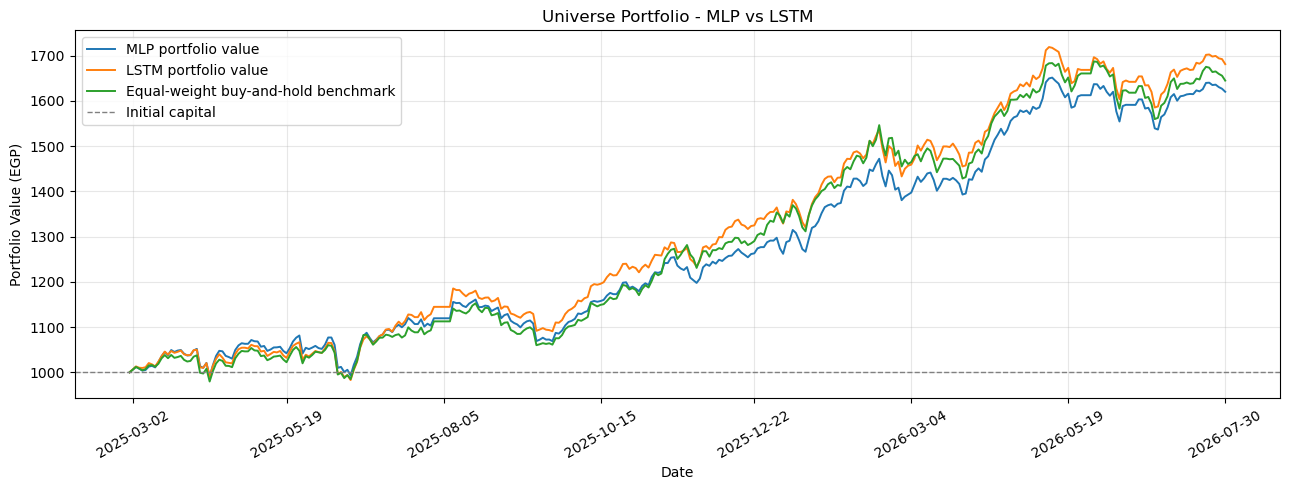

In [227]:
universe_x = np.arange(len(common_portfolio_dates))
universe_x_with_start = np.arange(len(common_portfolio_dates) + 1)

tick_count = min(8, len(common_portfolio_dates))
tick_positions = np.linspace(0, len(common_portfolio_dates) - 1, num=tick_count, dtype=int)
tick_labels = [str(common_portfolio_dates[pos])[:10] for pos in tick_positions]
tick_positions_with_start = tick_positions + 1

plt.figure(figsize=(13, 5))
plt.plot(universe_x_with_start, mlp_universe_portfolio_values, label="MLP portfolio value", linewidth=1.4)
plt.plot(universe_x_with_start, lstm_universe_portfolio_values, label="LSTM portfolio value", linewidth=1.4)
plt.plot(universe_x_with_start, benchmark_portfolio_values, label="Equal-weight buy-and-hold benchmark", linewidth=1.4)
plt.axhline(initial_universe_portfolio, color="gray", linestyle="--", linewidth=1.0, label="Initial capital")
plt.title("Universe Portfolio - MLP vs LSTM")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (EGP)")
plt.xticks(tick_positions_with_start, tick_labels, rotation=30)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


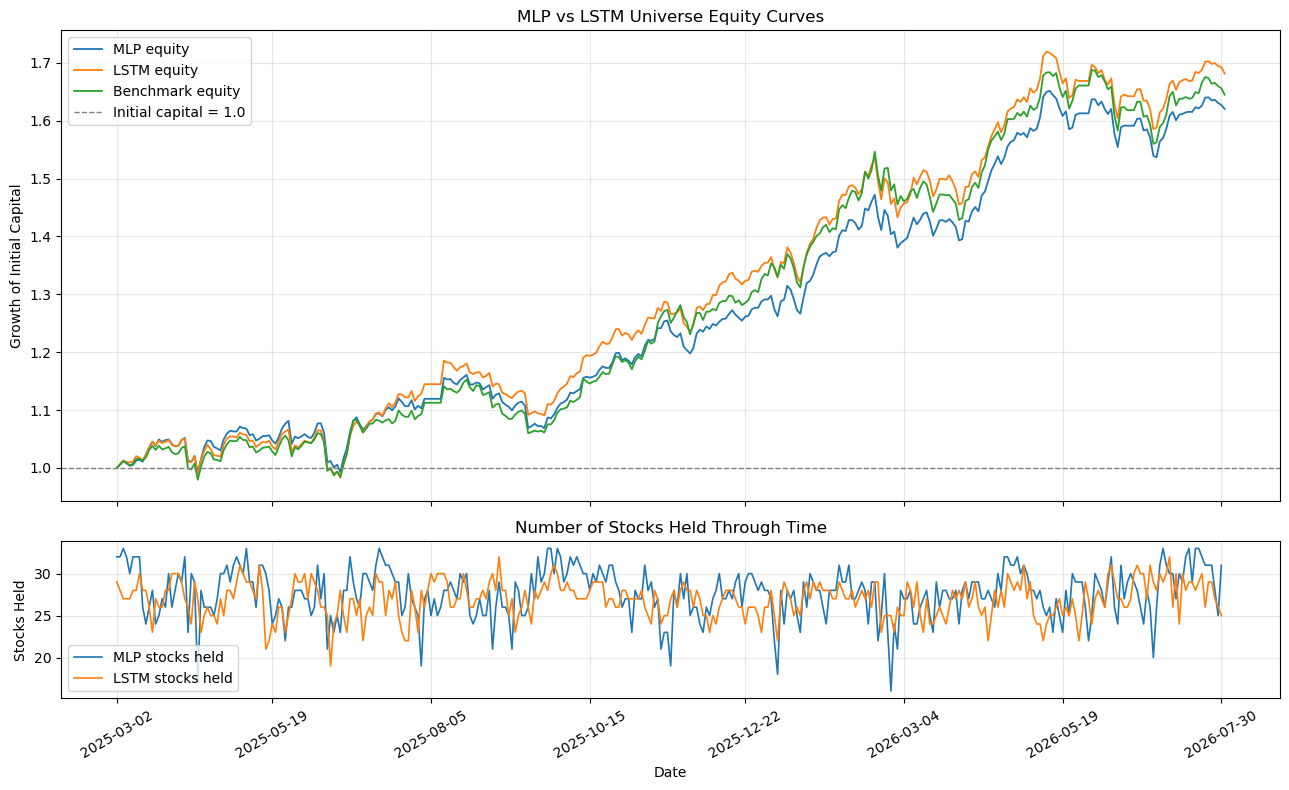

In [228]:
mlp_universe_equity = mlp_universe_portfolio_values / initial_universe_portfolio
lstm_universe_equity = lstm_universe_portfolio_values / initial_universe_portfolio
benchmark_universe_equity = benchmark_portfolio_values / initial_universe_portfolio

fig, (ax_equity, ax_held) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax_equity.plot(universe_x_with_start, mlp_universe_equity, label="MLP equity", linewidth=1.3)
ax_equity.plot(universe_x_with_start, lstm_universe_equity, label="LSTM equity", linewidth=1.3)
ax_equity.plot(universe_x_with_start, benchmark_universe_equity, label="Benchmark equity", linewidth=1.3)
ax_equity.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, label="Initial capital = 1.0")
ax_equity.set_title("MLP vs LSTM Universe Equity Curves")
ax_equity.set_ylabel("Growth of Initial Capital")
ax_equity.legend()
ax_equity.grid(alpha=0.3)

ax_held.plot(universe_x, mlp_number_selected, label="MLP stocks held", linewidth=1.2)
ax_held.plot(universe_x, lstm_number_selected, label="LSTM stocks held", linewidth=1.2)
ax_held.set_title("Number of Stocks Held Through Time")
ax_held.set_ylabel("Stocks Held")
ax_held.set_xlabel("Date")
ax_held.set_xticks(tick_positions, tick_labels, rotation=30)
ax_held.legend()
ax_held.grid(alpha=0.3)

fig.tight_layout()
plt.show()


In [229]:
multi_stock_summary_lines = [
    "## MULTI-STOCK TEST PORTFOLIO",
    "",
    "| Metric | MLP | LSTM | Benchmark |",
    "|---|---:|---:|---:|",
    f"| Initial value (EGP) | {mlp_universe_summary['initial_value']:.2f} | {lstm_universe_summary['initial_value']:.2f} | {benchmark_universe_summary['initial_value']:.2f} |",
    f"| Final value (EGP) | {mlp_universe_summary['final_value']:.2f} | {lstm_universe_summary['final_value']:.2f} | {benchmark_universe_summary['final_value']:.2f} |",
    f"| Profit / loss (EGP) | {mlp_universe_summary['profit_loss']:.2f} | {lstm_universe_summary['profit_loss']:.2f} | {benchmark_universe_summary['profit_loss']:.2f} |",
    f"| Total return (%) | {mlp_universe_summary['total_return_pct']:.2f}% | {lstm_universe_summary['total_return_pct']:.2f}% | {benchmark_universe_summary['total_return_pct']:.2f}% |",
    f"| Maximum drawdown (%) | {mlp_universe_summary['max_drawdown_pct']:.2f}% | {lstm_universe_summary['max_drawdown_pct']:.2f}% | {benchmark_universe_summary['max_drawdown_pct']:.2f}% |",
    f"| Market exposure (%) | {mlp_universe_summary['market_exposure_pct']:.2f}% | {lstm_universe_summary['market_exposure_pct']:.2f}% | {benchmark_universe_summary['market_exposure_pct']:.2f}% |",
    f"| Average stocks held | {mlp_universe_summary['average_number_selected']:.2f} | {lstm_universe_summary['average_number_selected']:.2f} | {benchmark_universe_summary['average_number_selected']:.2f} |",
    f"| Minimum stocks held | {mlp_universe_summary['minimum_number_selected']} | {lstm_universe_summary['minimum_number_selected']} | {benchmark_universe_summary['minimum_number_selected']} |",
    f"| Maximum stocks held | {mlp_universe_summary['maximum_number_selected']} | {lstm_universe_summary['maximum_number_selected']} | {benchmark_universe_summary['maximum_number_selected']} |",
    f"| Sharpe ratio | {mlp_universe_summary['sharpe']:.2f} | {lstm_universe_summary['sharpe']:.2f} | {benchmark_universe_summary['sharpe']:.2f} |",
]
display(Markdown("\n".join(multi_stock_summary_lines)))


## MULTI-STOCK TEST PORTFOLIO

| Metric | MLP | LSTM | Benchmark |
|---|---:|---:|---:|
| Initial value (EGP) | 1000.00 | 1000.00 | 1000.00 |
| Final value (EGP) | 1620.29 | 1681.42 | 1644.98 |
| Profit / loss (EGP) | 620.29 | 681.42 | 644.98 |
| Total return (%) | 62.03% | 68.14% | 64.50% |
| Maximum drawdown (%) | 8.19% | 7.99% | 8.03% |
| Market exposure (%) | 100.00% | 100.00% | 100.00% |
| Average stocks held | 27.71 | 26.94 | 34.00 |
| Minimum stocks held | 16 | 19 | 34 |
| Maximum stocks held | 33 | 32 | 34 |
| Sharpe ratio | 2.27 | 2.36 | 2.23 |

## Did Memory Help the Portfolio?

This answer should be based on the portfolio results above, not only on single-stock forecast accuracy.


In [230]:
mlp_beats_universe_benchmark = mlp_universe_summary["final_value"] > benchmark_universe_summary["final_value"]
lstm_beats_universe_benchmark = lstm_universe_summary["final_value"] > benchmark_universe_summary["final_value"]

if lstm_universe_summary["final_value"] > mlp_universe_summary["final_value"]:
    better_universe_portfolio = "LSTM"
elif mlp_universe_summary["final_value"] > lstm_universe_summary["final_value"]:
    better_universe_portfolio = "MLP"
else:
    better_universe_portfolio = "Tie"

universe_interpretation_lines = [
    f"1. Higher final portfolio value: **{better_universe_portfolio}**",
    f"2. Higher total return: **{'LSTM' if lstm_universe_summary['total_return_pct'] > mlp_universe_summary['total_return_pct'] else 'MLP' if mlp_universe_summary['total_return_pct'] > lstm_universe_summary['total_return_pct'] else 'Tie'}**",
    f"3. Lower maximum drawdown: **{'MLP' if mlp_universe_summary['max_drawdown_pct'] < lstm_universe_summary['max_drawdown_pct'] else 'LSTM' if lstm_universe_summary['max_drawdown_pct'] < mlp_universe_summary['max_drawdown_pct'] else 'Tie'}**",
    f"4. Higher average stocks held: **{'MLP' if mlp_universe_summary['average_number_selected'] > lstm_universe_summary['average_number_selected'] else 'LSTM' if lstm_universe_summary['average_number_selected'] > mlp_universe_summary['average_number_selected'] else 'Tie'}**",
    f"5. More time invested: **{'MLP' if mlp_universe_summary['market_exposure_pct'] > lstm_universe_summary['market_exposure_pct'] else 'LSTM' if lstm_universe_summary['market_exposure_pct'] > mlp_universe_summary['market_exposure_pct'] else 'Tie'}**",
    f"6. Did MLP beat the equal-weight benchmark? **{'Yes' if mlp_beats_universe_benchmark else 'No'}**",
    f"7. Did LSTM beat the equal-weight benchmark? **{'Yes' if lstm_beats_universe_benchmark else 'No'}**",
    f"8. Did the model with better ABUK prediction accuracy also create the better multi-stock portfolio? **{'Yes' if better_universe_portfolio == 'LSTM' else 'No'}**. Earlier in the notebook, the LSTM had lower ABUK test MSE and higher ABUK information coefficient; in this diversified universe test, the LSTM also finished with the higher final portfolio value.",
]
display(Markdown("\n".join(universe_interpretation_lines)))


1. Higher final portfolio value: **LSTM**
2. Higher total return: **LSTM**
3. Lower maximum drawdown: **LSTM**
4. Higher average stocks held: **MLP**
5. More time invested: **Tie**
6. Did MLP beat the equal-weight benchmark? **No**
7. Did LSTM beat the equal-weight benchmark? **Yes**
8. Did the model with better ABUK prediction accuracy also create the better multi-stock portfolio? **Yes**. Earlier in the notebook, the LSTM had lower ABUK test MSE and higher ABUK information coefficient; in this diversified universe test, the LSTM also finished with the higher final portfolio value.

The earlier ABUK-only experiment and the new universe portfolio answer slightly different questions. A model that looks mixed or weak on one stock can behave differently once predictions are diversified across many names, because diversification changes both return and drawdown.


In [231]:
single_vs_multi_lines = [
    "## Single-Stock vs Multi-Stock Discussion",
    "",
    f"- Earlier ABUK-only signal result: the **MLP** produced the better single-stock ABUK trading portfolio (`{mlp_portfolio['final_value']:.2f}` EGP vs `{lstm_portfolio['final_value']:.2f}` EGP).",
    f"- New universe result: the **LSTM** produced the better diversified multi-stock portfolio (`{lstm_universe_summary['final_value']:.2f}` EGP vs `{mlp_universe_summary['final_value']:.2f}` EGP).",
    "- That means the multi-stock result does **not** simply repeat the ABUK-only story. Diversifying signals across many stocks changed the return and drawdown profile enough that memory helped more at the universe-portfolio level than it did in the earlier single-stock trading section.",
]
display(Markdown("\n".join(single_vs_multi_lines)))


## Single-Stock vs Multi-Stock Discussion

- Earlier ABUK-only signal result: the **MLP** produced the better single-stock ABUK trading portfolio (`3371.15` EGP vs `2272.43` EGP).
- New universe result: the **LSTM** produced the better diversified multi-stock portfolio (`1681.42` EGP vs `1620.29` EGP).
- That means the multi-stock result does **not** simply repeat the ABUK-only story. Diversifying signals across many stocks changed the return and drawdown profile enough that memory helped more at the universe-portfolio level than it did in the earlier single-stock trading section.